# JNM Fermentation Data Analysis
## Carotenoid-producing *S. cerevisiae* — Fed-Batch Process Investigation

**Objective:** Investigate low biomass yield across 6 bench-top fermenter batches (B01–B06).  
**Data source:** Client batch reports (OD600, WCW, pO₂, feed rates at 6h intervals).  
**Key gap:** No glucose, ethanol, or product measurements available.

---

### Analyses in this notebook:
1. **Volumetric Productivity Reconstruction** — volume-corrected biomass mass
2. **Growth Phase Segmentation** — identify batch, exponential, linear, stationary, decline
3. **Specific Growth Rate (μ)** — smoothed μ from DCW mass curves
4. **pO₂–μ Cross-Correlation** — oxygen limitation assessment with C_critical context
5. **Carbon Balance Envelope** — glucose in vs biomass out
6. **Glucose Concentration / Crabtree Flag** — estimate residual glucose, flag overflow risk
7. **OD/WCW Ratio Trajectory** — cell composition/cycle indicator
8. **kLa Estimates** — oxygen transfer capacity assessment with sensitivity analysis

## 0. Setup and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotly for interactive exploration
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print('Plotly not installed — interactive plots will be skipped.')

# Import our toolkit
from fermentation_toolkit import (
    load_batch_data, load_metadata,
    reconstruct_volume, compute_dcw, compute_mu,
    segment_growth_phases, compute_carbon_balance,
    estimate_glucose_concentration, compute_od_wcw_ratio,
    estimate_our, estimate_kla, kla_sensitivity,
    compute_glucose_fed, process_all_batches,
    BATCH_COLORS, PHASE_COLORS
)

# Matplotlib defaults
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.family'] = 'sans-serif'

print('Setup complete.')

Setup complete.


### PARAMS — Literature Constants & Assumptions

**All tunable parameters are collected here.** Change a value and re-run the notebook to see the effect.

| Parameter | Value | Source |
|---|---|---|
| DCW/WCW ratio | 0.25 | Shuler & Kargi (2002) *Bioprocess Engineering: Basic Concepts* |
| Yx/s (biomass/glucose) | 0.45 g/g | Theoretical aerobic yield for *S. cerevisiae*; Reference: Roels, J. A. (1983). Energetics and Kinetics in Biotechnology. |
| Y_X/O₂ (biomass/oxygen) | 1.25 g/g | Verduyn et al. (1991); Heijnen & Van Dijken (1992); Atkinson & Mavituna (1991) |
| mO₂ (maintenance O₂) | 1.0 mmol O₂/g DCW/h | Verduyn et al. (1991); Sonnleitner & Käppeli (1986); Van den Berg et al. (2013) |
| C_critical (DO) | 10–15% air sat. | Standard for *S. cerevisiae*; Sonnleitner, B., & Käppeli, O. (1986). "Growth of Saccharomyces cerevisiae is controlled by its limited respiratory capacity: Formulation and verification of a hypothesis." Biotechnology and Bioengineering, 28(6), 927-937. |
| Crabtree threshold | 0.1 g/L glucose | Overflow metabolism onset for *S. cerevisiae*; Verduyn, C. (1991). "Physiology of Yeasts in Relation to Biomass Yields." |
| qs_critical | 0.25 g/g/h | Specific glucose feed rate above which Crabtree activates; Postma et al. (1989); Van Hoek, P., et al. (1998). "Effects of specific growth rate on biomass yield and glycolytic flux in Saccharomyces cerevisiae." Appl. Environ. Microbiol. |
| C* (DO saturation) | 7.3 mg/L | At 30°C, 1 atm, air sparging, in media with salts; Schumpe, A., et al. (1982). "The solubility of oxygen in electrolyte solutions." Adv. Biochem. Eng.  |
| Glucose in feed | 620 g/L | From client batch reports |
| Glucose in batch medium | 20 g/L | From client batch reports |
| Glucose in pulse (B04) | 500 g/L | 50% w/v glucose bolus |
| Sample volume | 3 mL | WCW measurement takes 3 mL per timepoint |

**OUR estimation — Pirt equation:**  
OUR = (μ / Y<sub>X/O₂,max</sub> + m<sub>O₂</sub>) × X  
- First term = growth-associated O₂ demand  
- Second term = maintenance O₂ demand (cells "breathe" even at μ ≈ 0)  
- Y<sub>X/O₂,max</sub> converted from g/g to g/mmol: 1.25 g/g ÷ 31.25 mmol/g = 0.04 g/mmol  
- Refs: Pirt (1965); Verduyn et al. (1991); Van den Berg et al. (2013); Sonnleitner & Käppeli (1986)

**Per-batch initial volumes** (from client batch reports — batch medium + inoculum):

| Batch | Batch medium (mL) | Inoculum (mL) | V_initial (mL) |
|---|---|---|---|
| B01 | 1500 | 100 | 1600 |
| B02 | 1500 | 100 | 1600 |
| B03 | 1500 | 100 | 1600 |
| B04 | 1500 | 200 | 1700 |
| B05 | 1500 | 100 | 1600 |
| B06 | 1500 | 100 | 1600 |

*Note: Glucose calculations use the batch medium volume (not V_initial), since the inoculum does not contain 20 g/L glucose.*

In [3]:
PARAMS = {
    # --- Biomass conversion ---
    'dcw_wcw_ratio': 0.25,          # g DCW / g WCW
                                     # Ref: Shuler, M. L., & Kargi, F. (2002).
                                     # Bioprocess Engineering: Basic Concepts.

    # --- Yield coefficients ---
    'Yxs': 0.45,                    # g DCW / g glucose (aerobic, S. cerevisiae)
    'Y_XO2': 1.25,                  # g DCW / g O2 (midpoint of 1.0-1.5 range)
                                     # Refs: Verduyn, C., et al. (1991). Energetics of
                                     #   S. cerevisiae in anaerobic and aerobic glucose-limited
                                     #   chemostat cultures.
                                     # Shuler & Kargi (2002). Yx/O2 = 1.0-1.5 g/g.
                                     # Heijnen, J. J., & Van Dijken, J. P. (1992).
                                     #   In search of a thermodynamic description of
                                     #   biomass yields for chemotrophic growth.
                                     # Atkinson, B., & Mavituna, F. (1991).
                                     #   Biochemical Engineering & Biotechnology Handbook.

    # --- Oxygen parameters ---
    'C_star_mgL': 7.3,              # Saturated DO at 30C, 1 atm, air sparging (mg/L)
    'C_critical_pct': 12.5,         # Critical DO for S. cerevisiae (% air saturation)
                                     # Range: 10-15% air sat.
    'mO2_mmol_gDCW_h': 1.0,        # Maintenance oxygen coefficient (mmol O2 / g DCW / h)
                                     # S. cerevisiae at 30C, aerobic.
                                     # Refs: Verduyn et al. (1991) — measured 0.5-1.5 range
                                     #   depending on growth conditions.
                                     # Van den Berg et al. (2013) — 1.0 as central estimate.
                                     # Sonnleitner, B., & Kappeli, O. (1986). Growth of
                                     #   S. cerevisiae is controlled by its limited
                                     #   respiratory capacity. Biotechnol. Bioeng. 28.
                                     # Pirt, S. J. (1965). The maintenance energy of
                                     #   bacteria in growing cultures. Proc. R. Soc. Lond. B.
                                     # Unit conversion note: Y_XO2 1.25 g/g => 0.04 g/mmol
                                     #   (1 g O2 = 31.25 mmol O2)

    # --- Glucose / Crabtree ---
    'glucose_conc_feed_gL': 620.0,  # g glucose / L of feed solution
    'glucose_conc_batch_gL': 20.0,  # g glucose / L of batch medium
    'glucose_conc_pulse_gL': 500.0, # 50% w/v glucose for B04 pulses
    'crabtree_threshold_gL': 0.1,   # g/L glucose above which Crabtree kicks in
    'qs_critical_ggh': 0.25,        # Critical specific glucose feed rate (g/g/h)
                                     # Above this, S. cerevisiae overflow -> ethanol
                                     # Ref: Postma et al. (1989); Van Hoek et al. (1998)

    # --- Per-batch initial volumes (from PDF: batch medium + inoculum) ---
    # V_initial_mL: total liquid in reactor at t=0 (batch medium + inoculum)
    # V_batch_medium_mL: batch medium volume only (used for initial glucose calc,
    #   since inoculum does not contain 20 g/L glucose)
    #
    # Source: Client batch reports
    #   B01: 1500 mL batch medium + 100 mL inoculum
    #   B02: identical to B01
    #   B03: identical to B01
    #   B04: 1500 mL batch medium + 200 mL inoculum (Sartorius BIOSTAT B, 2L scale)
    #   B05: 1500 mL batch medium + 100 mL inoculum (Sartorius BIOSTAT B, 1L scale)
    #   B06: identical to B05
    'V_initial_mL': {
        'B01': 1600,    # 1500 + 100
        'B02': 1600,    # 1500 + 100
        'B03': 1600,    # 1500 + 100
        'B04': 1700,    # 1500 + 200
        'B05': 1600,    # 1500 + 100
        'B06': 1600,    # 1500 + 100
    },
    'V_batch_medium_mL': {
        'B01': 1500,
        'B02': 1500,
        'B03': 1500,
        'B04': 1500,
        'B05': 1500,
        'B06': 1500,
    },

    # --- Sampling ---
    'sample_volume_mL': 3.0,        # mL removed per sample (WCW measurement)

    # --- Smoothing ---
    'savgol_window': 5,             # Savitzky-Golay window size
    'savgol_order': 2,              # Savitzky-Golay polynomial order

    # --- Phase segmentation thresholds ---
    'mu_exponential_threshold': 0.05,  # h^-1; above this = exponential phase
    'mu_decline_threshold': -0.005,    # h^-1; below this = decline
    'mu_stationary_band': 0.01,        # h^-1; within this band = stationary
}

print('PARAMS loaded. Key values:')
for k, v in PARAMS.items():
    if isinstance(v, dict):
        print(f'  {k}:')
        for kk, vv in v.items():
            print(f'    {kk}: {vv}')
    else:
        print(f'  {k}: {v}')

PARAMS loaded. Key values:
  dcw_wcw_ratio: 0.25
  Yxs: 0.45
  Y_XO2: 1.25
  C_star_mgL: 7.3
  C_critical_pct: 12.5
  mO2_mmol_gDCW_h: 1.0
  glucose_conc_feed_gL: 620.0
  glucose_conc_batch_gL: 20.0
  glucose_conc_pulse_gL: 500.0
  crabtree_threshold_gL: 0.1
  qs_critical_ggh: 0.25
  V_initial_mL:
    B01: 1600
    B02: 1600
    B03: 1600
    B04: 1700
    B05: 1600
    B06: 1600
  V_batch_medium_mL:
    B01: 1500
    B02: 1500
    B03: 1500
    B04: 1500
    B05: 1500
    B06: 1500
  sample_volume_mL: 3.0
  savgol_window: 5
  savgol_order: 2
  mu_exponential_threshold: 0.05
  mu_decline_threshold: -0.005
  mu_stationary_band: 0.01


### Load Data

In [4]:
# Load raw data and metadata
data = load_batch_data('batch_data.csv')
metadata = load_metadata('batch_metadata.csv')

print(f'Batch data: {len(data)} rows across {data["Batch"].nunique()} batches')
print(f'Metadata: {len(metadata)} entries')
print(f'\nBatches: {sorted(data["Batch"].unique())}')
print(f'\nTimepoints per batch:')
print(data.groupby('Batch')['Time_h'].count())

Batch data: 103 rows across 6 batches
Metadata: 85 entries

Batches: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06']

Timepoints per batch:
Batch
B01    15
B02    17
B03    15
B04    14
B05    21
B06    21
Name: Time_h, dtype: int64


In [5]:
# Run the full processing pipeline on all batches
batches = process_all_batches(data, metadata, PARAMS)

# Quick sanity check: show final volumes and DCW
summary_rows = []
for b, df in sorted(batches.items()):
    summary_rows.append({
        'Batch': b,
        'Duration_h': df['Time_h'].max(),
        'V_initial_mL': df['Volume_mL'].iloc[0],
        'V_final_mL': round(df['Volume_mL'].iloc[-1], 0),
        'V_increase_%': round((df['Volume_mL'].iloc[-1] / df['Volume_mL'].iloc[0] - 1) * 100, 1),
        'DCW_final_gL': round(df['DCW_gL'].iloc[-1], 1),
        'DCW_mass_final_g': round(df['DCW_mass_g'].iloc[-1], 1),
        'Cumul_Feed_mL': round(df['Cumul_Feed_mL'].iloc[-1], 0),
    })

summary_df = pd.DataFrame(summary_rows)
print('\n=== Processing Pipeline Complete ===')
display(summary_df)


=== Processing Pipeline Complete ===


,Batch,Duration_h,V_initial_mL,V_final_mL,V_increase_%,DCW_final_gL,DCW_mass_final_g,Cumul_Feed_mL
0,B01,82,1600.0,3031.0,89.4,48.8,147.8,1473.0
1,B02,96,1600.0,3733.0,133.3,47.6,177.8,2181.0
2,B03,84,1600.0,3123.0,95.2,65.4,204.4,1565.0
3,B04,74,1700.0,3812.0,124.2,95.8,365.0,1480.0
4,B05,120,1600.0,3911.0,144.4,85.1,332.8,1971.0
5,B06,120,1600.0,4442.0,177.6,81.9,363.9,2412.0


---
## Analysis 1: Volumetric Productivity Reconstruction

The law of conservation applies to **mass**, not concentration. Since feeding dilutes the culture while adding volume, we must:
1. Reconstruct reactor volume V(t) at each timepoint
2. Convert WCW concentration → DCW concentration (DCW = 0.25 × WCW; Shuler & Kargi, 2002)
3. Compute **total DCW mass** = DCW_gL × V(t)

This corrects for the dilution artifact where concentration appears flat or declining even though total biomass is growing.

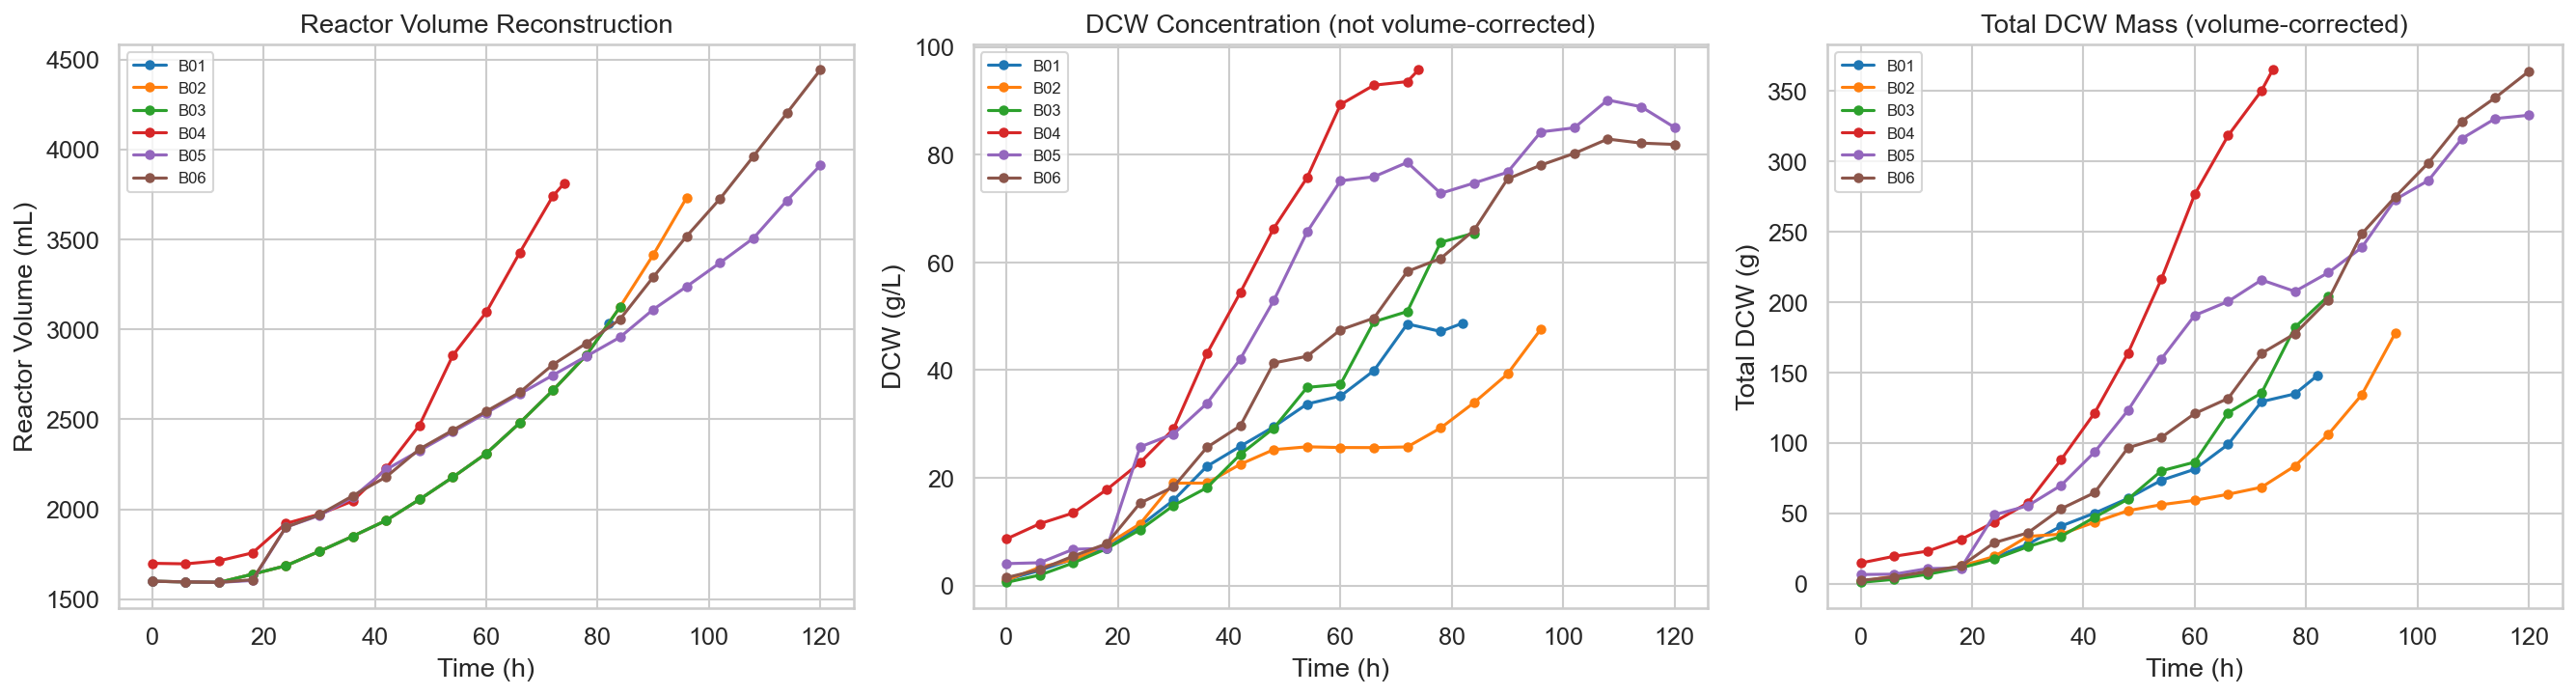

In [6]:
# --- Plot 1a: Reactor volume over time ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Volume
ax = axes[0]
for b, df in sorted(batches.items()):
    ax.plot(df['Time_h'], df['Volume_mL'], 'o-', label=b,
            color=BATCH_COLORS[b], markersize=4)
ax.set_xlabel('Time (h)')
ax.set_ylabel('Reactor Volume (mL)')
ax.set_title('Reactor Volume Reconstruction')
ax.legend(fontsize=8)

# DCW concentration vs DCW mass
ax = axes[1]
for b, df in sorted(batches.items()):
    ax.plot(df['Time_h'], df['DCW_gL'], 'o-', label=b,
            color=BATCH_COLORS[b], markersize=4)
ax.set_xlabel('Time (h)')
ax.set_ylabel('DCW (g/L)')
ax.set_title('DCW Concentration (not volume-corrected)')
ax.legend(fontsize=8)

ax = axes[2]
for b, df in sorted(batches.items()):
    ax.plot(df['Time_h'], df['DCW_mass_g'], 'o-', label=b,
            color=BATCH_COLORS[b], markersize=4)
ax.set_xlabel('Time (h)')
ax.set_ylabel('Total DCW (g)')
ax.set_title('Total DCW Mass (volume-corrected)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

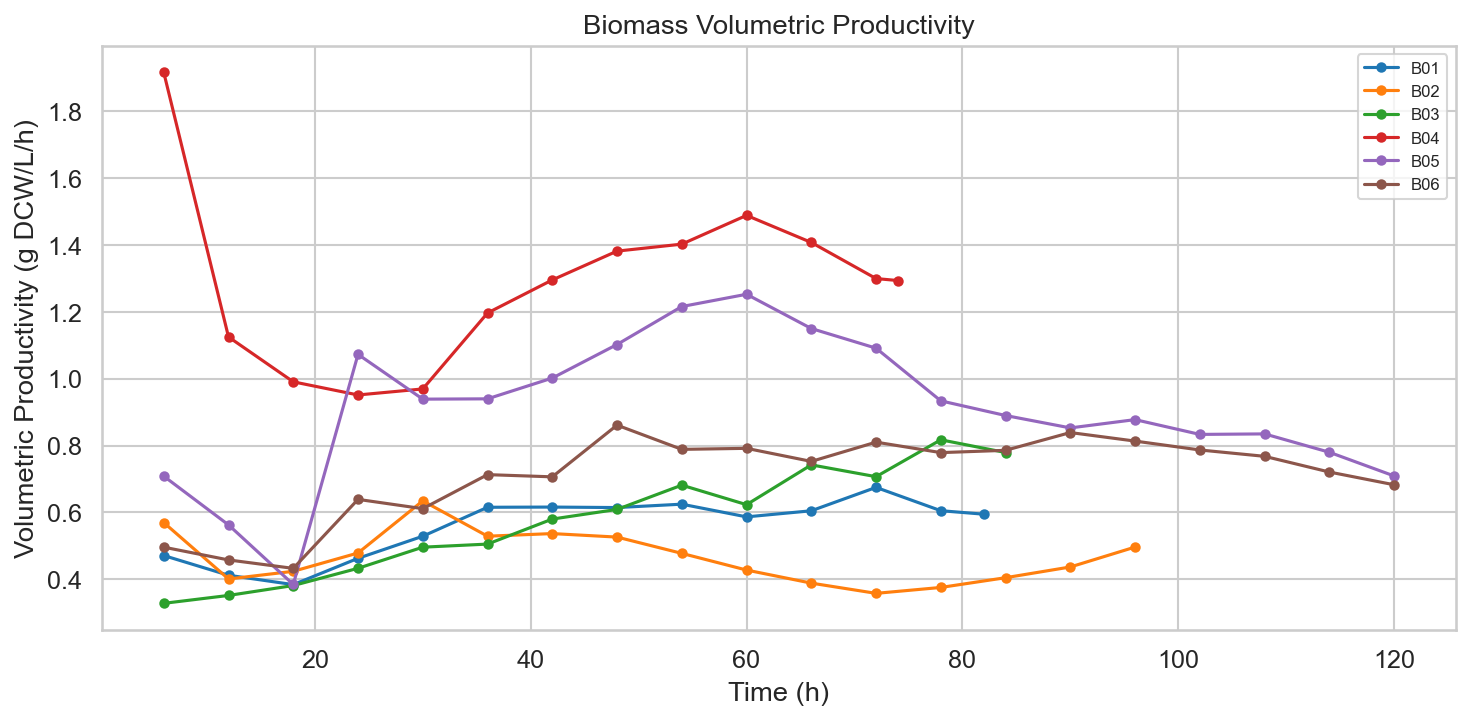

In [7]:
# --- Plot 1b: Volumetric productivity ---
fig, ax = plt.subplots(figsize=(10, 5))
for b, df in sorted(batches.items()):
    mask = df['Time_h'] > 0
    ax.plot(df.loc[mask, 'Time_h'], df.loc[mask, 'Vol_Productivity_gLh'],
            'o-', label=b, color=BATCH_COLORS[b], markersize=4)
ax.set_xlabel('Time (h)')
ax.set_ylabel('Volumetric Productivity (g DCW/L/h)')
ax.set_title('Biomass Volumetric Productivity')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# --- Interactive: volume components breakdown (Plotly) ---
if HAS_PLOTLY:
    fig = make_subplots(rows=2, cols=3,
                        subplot_titles=sorted(batches.keys()),
                        shared_yaxes=False)
    for idx, (b, df) in enumerate(sorted(batches.items())):
        r, c = idx // 3 + 1, idx % 3 + 1
        fig.add_trace(go.Scatter(x=df['Time_h'], y=df['Volume_mL'],
                                 name=f'{b} Volume', line=dict(color=BATCH_COLORS[b])),
                      row=r, col=c)
        fig.add_trace(go.Scatter(x=df['Time_h'], y=df['Cumul_Feed_mL'],
                                 name=f'{b} Feed', line=dict(color=BATCH_COLORS[b], dash='dot')),
                      row=r, col=c)
    fig.update_layout(height=600, title_text='Volume Reconstruction (hover for details)',
                      showlegend=False)
    fig.show()
else:
    print('Plotly not available — skipping interactive plot.')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

---
## Analysis 2: Growth Phase Segmentation

Using the volume-corrected **DCW mass** curves, identify:
- **Exponential phase**: high μ (rapid growth)
- **Linear phase**: μ declining but growth continues (nutrient-limited fed-batch)
- **Stationary phase**: μ ≈ 0
- **Decline phase**: μ < 0 (cell death, lysis)

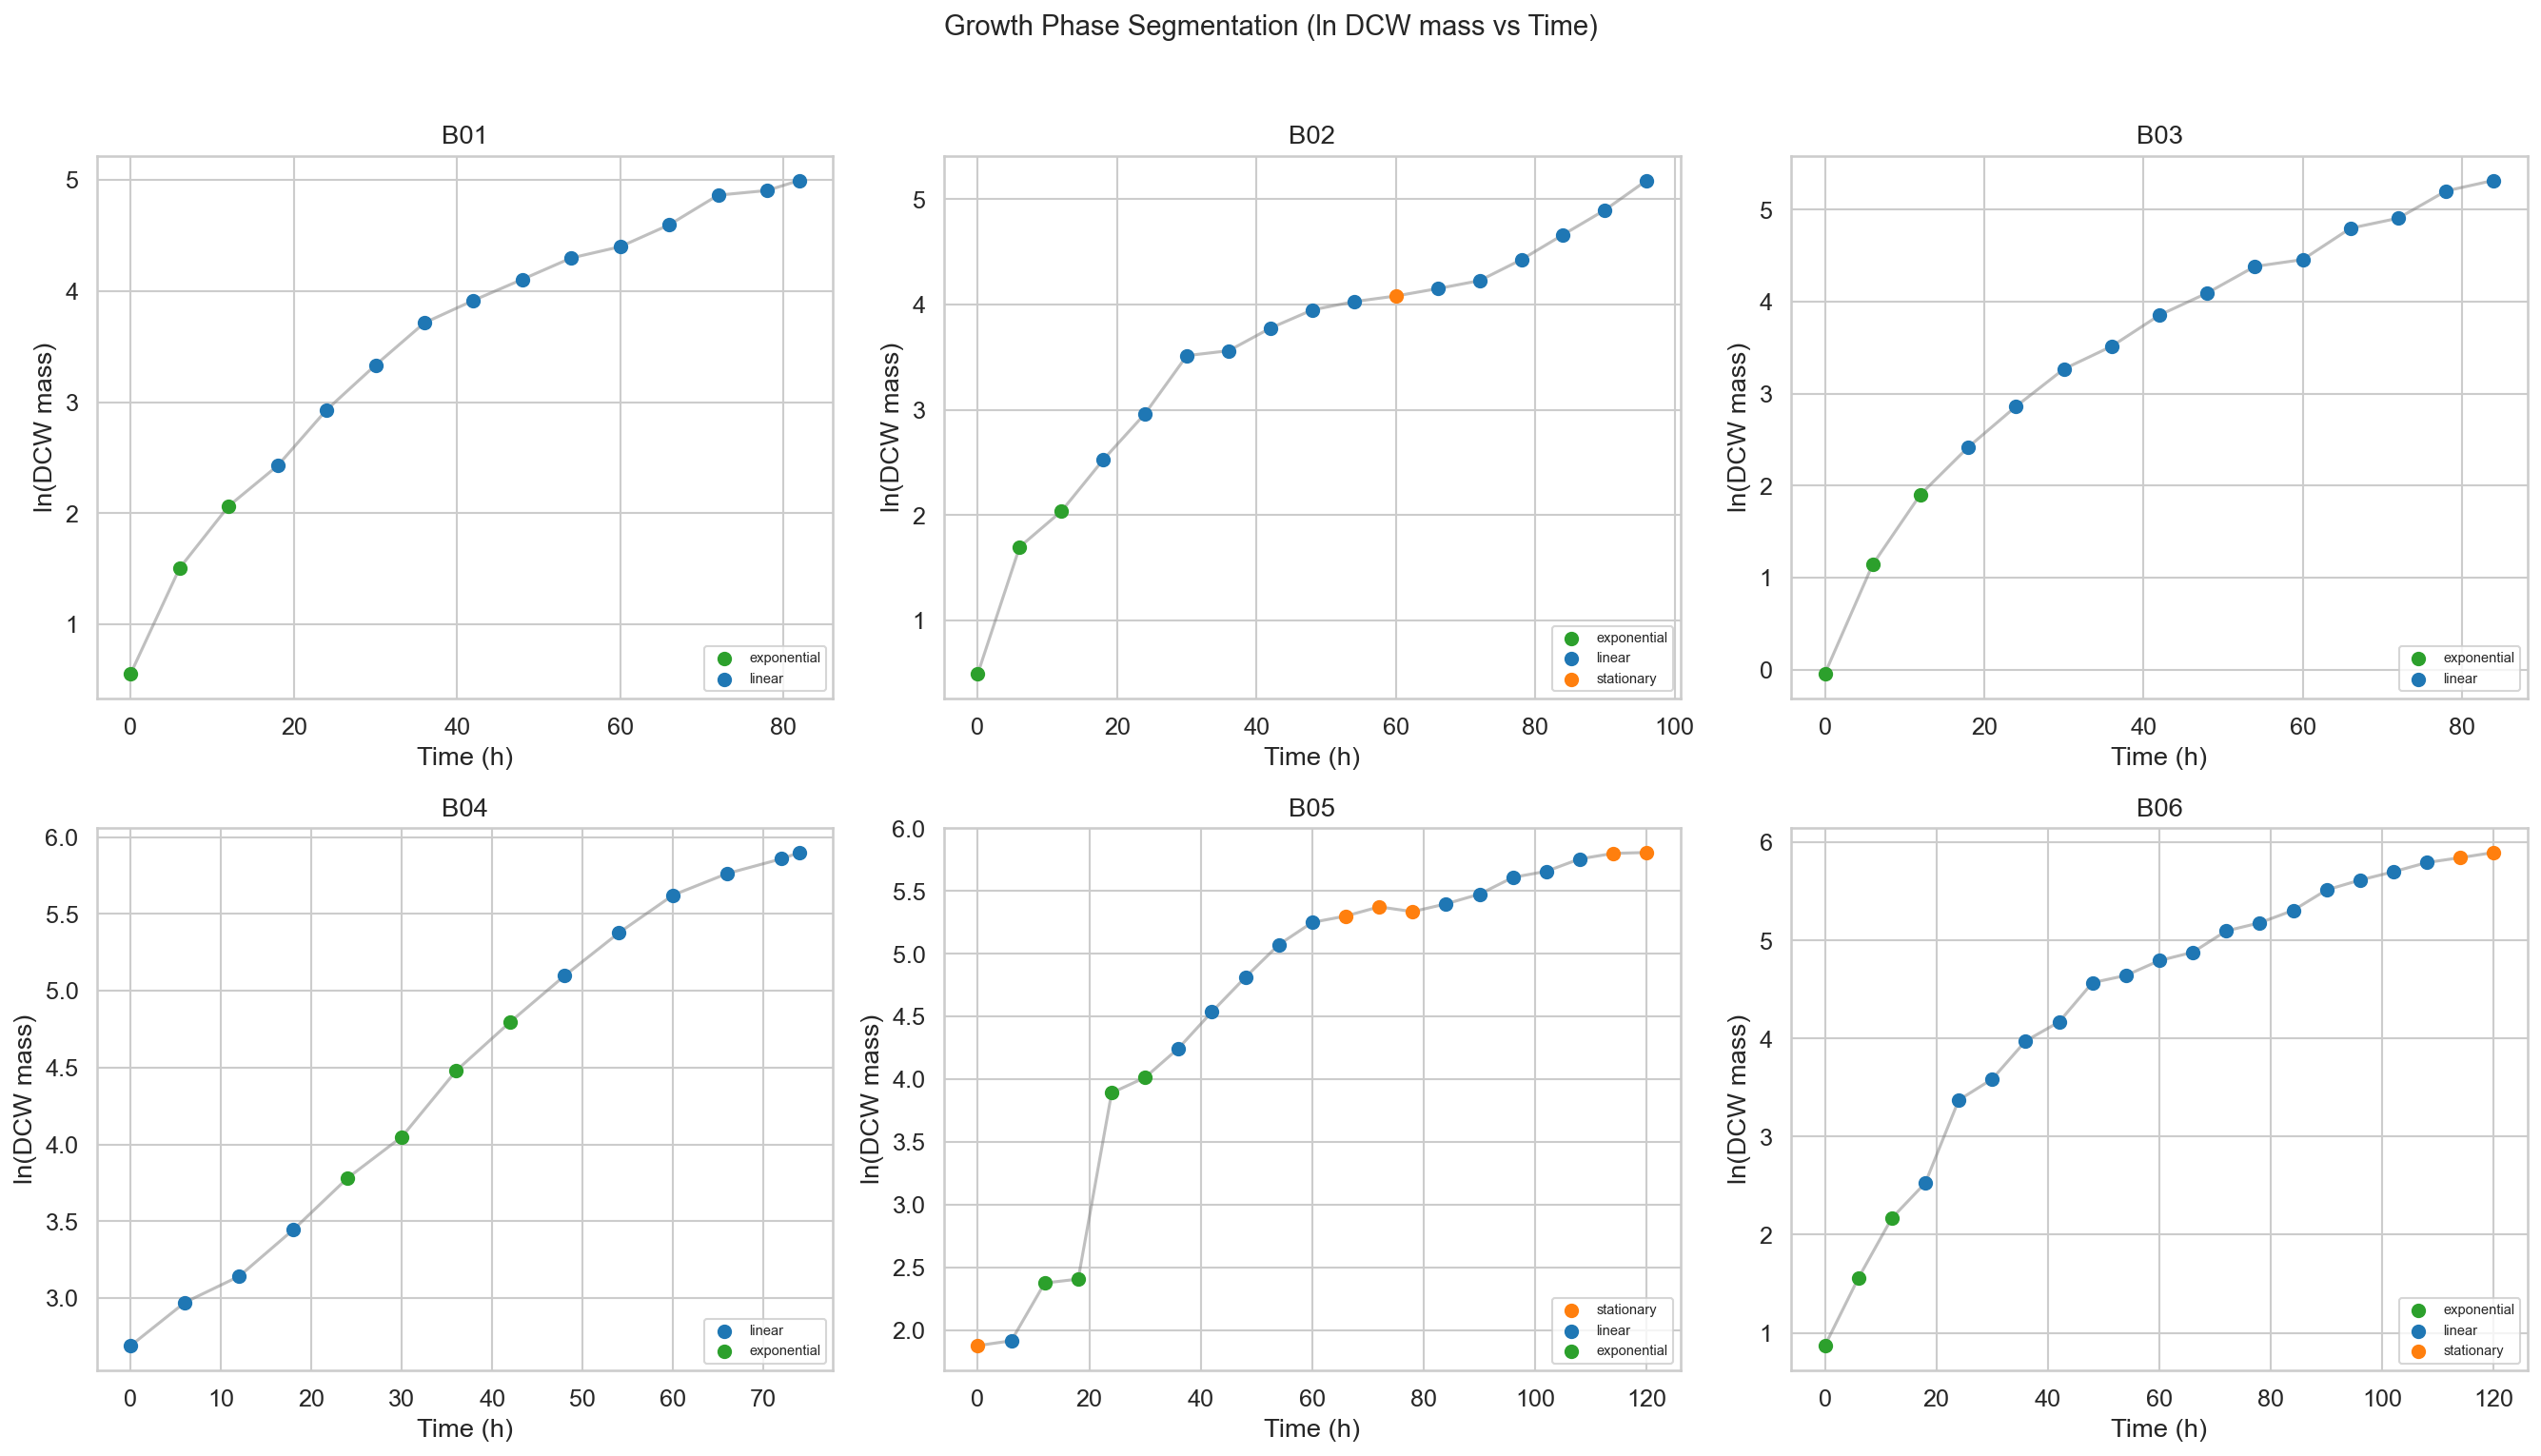

In [9]:
# --- Plot 2: Semi-log DCW mass with phase annotations ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (b, df) in enumerate(sorted(batches.items())):
    ax = axes[idx // 3][idx % 3]
    
    # Color-code by phase
    for phase in df['growth_phase'].unique():
        mask = df['growth_phase'] == phase
        ax.scatter(df.loc[mask, 'Time_h'], df.loc[mask, 'ln_DCW'],
                   c=PHASE_COLORS.get(phase, 'gray'), label=phase, s=40, zorder=3)
    
    ax.plot(df['Time_h'], df['ln_DCW'], '-', color='gray', alpha=0.5, zorder=2)
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('ln(DCW mass)')
    ax.set_title(f'{b}')
    ax.legend(fontsize=7, loc='lower right')

plt.suptitle('Growth Phase Segmentation (ln DCW mass vs Time)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# --- Phase duration summary table ---
phase_summary = []
for b, df in sorted(batches.items()):
    for phase in ['exponential', 'linear', 'stationary', 'decline']:
        mask = df['growth_phase'] == phase
        if mask.sum() > 0:
            t_min = df.loc[mask, 'Time_h'].min()
            t_max = df.loc[mask, 'Time_h'].max()
            phase_summary.append({
                'Batch': b, 'Phase': phase,
                'Start_h': t_min, 'End_h': t_max,
                'Duration_h': t_max - t_min,
                'n_points': mask.sum()
            })

phase_df = pd.DataFrame(phase_summary)
display(phase_df.pivot_table(index='Batch', columns='Phase',
                              values='Duration_h', aggfunc='first').fillna('-'))

Phase,exponential,linear,stationary
Batch,,,
B01,12.0,64.0,-
B02,12.0,78.0,0.0
B03,12.0,66.0,-
B04,18.0,74.0,-
B05,18.0,102.0,120.0
B06,12.0,90.0,6.0


---
## Analysis 3: Specific Growth Rate (μ)

μ is computed from **total DCW mass** (not concentration) to avoid the dilution artifact from feeding.  
μ = d(ln(mass_DCW)) / dt, smoothed with Savitzky-Golay filter.

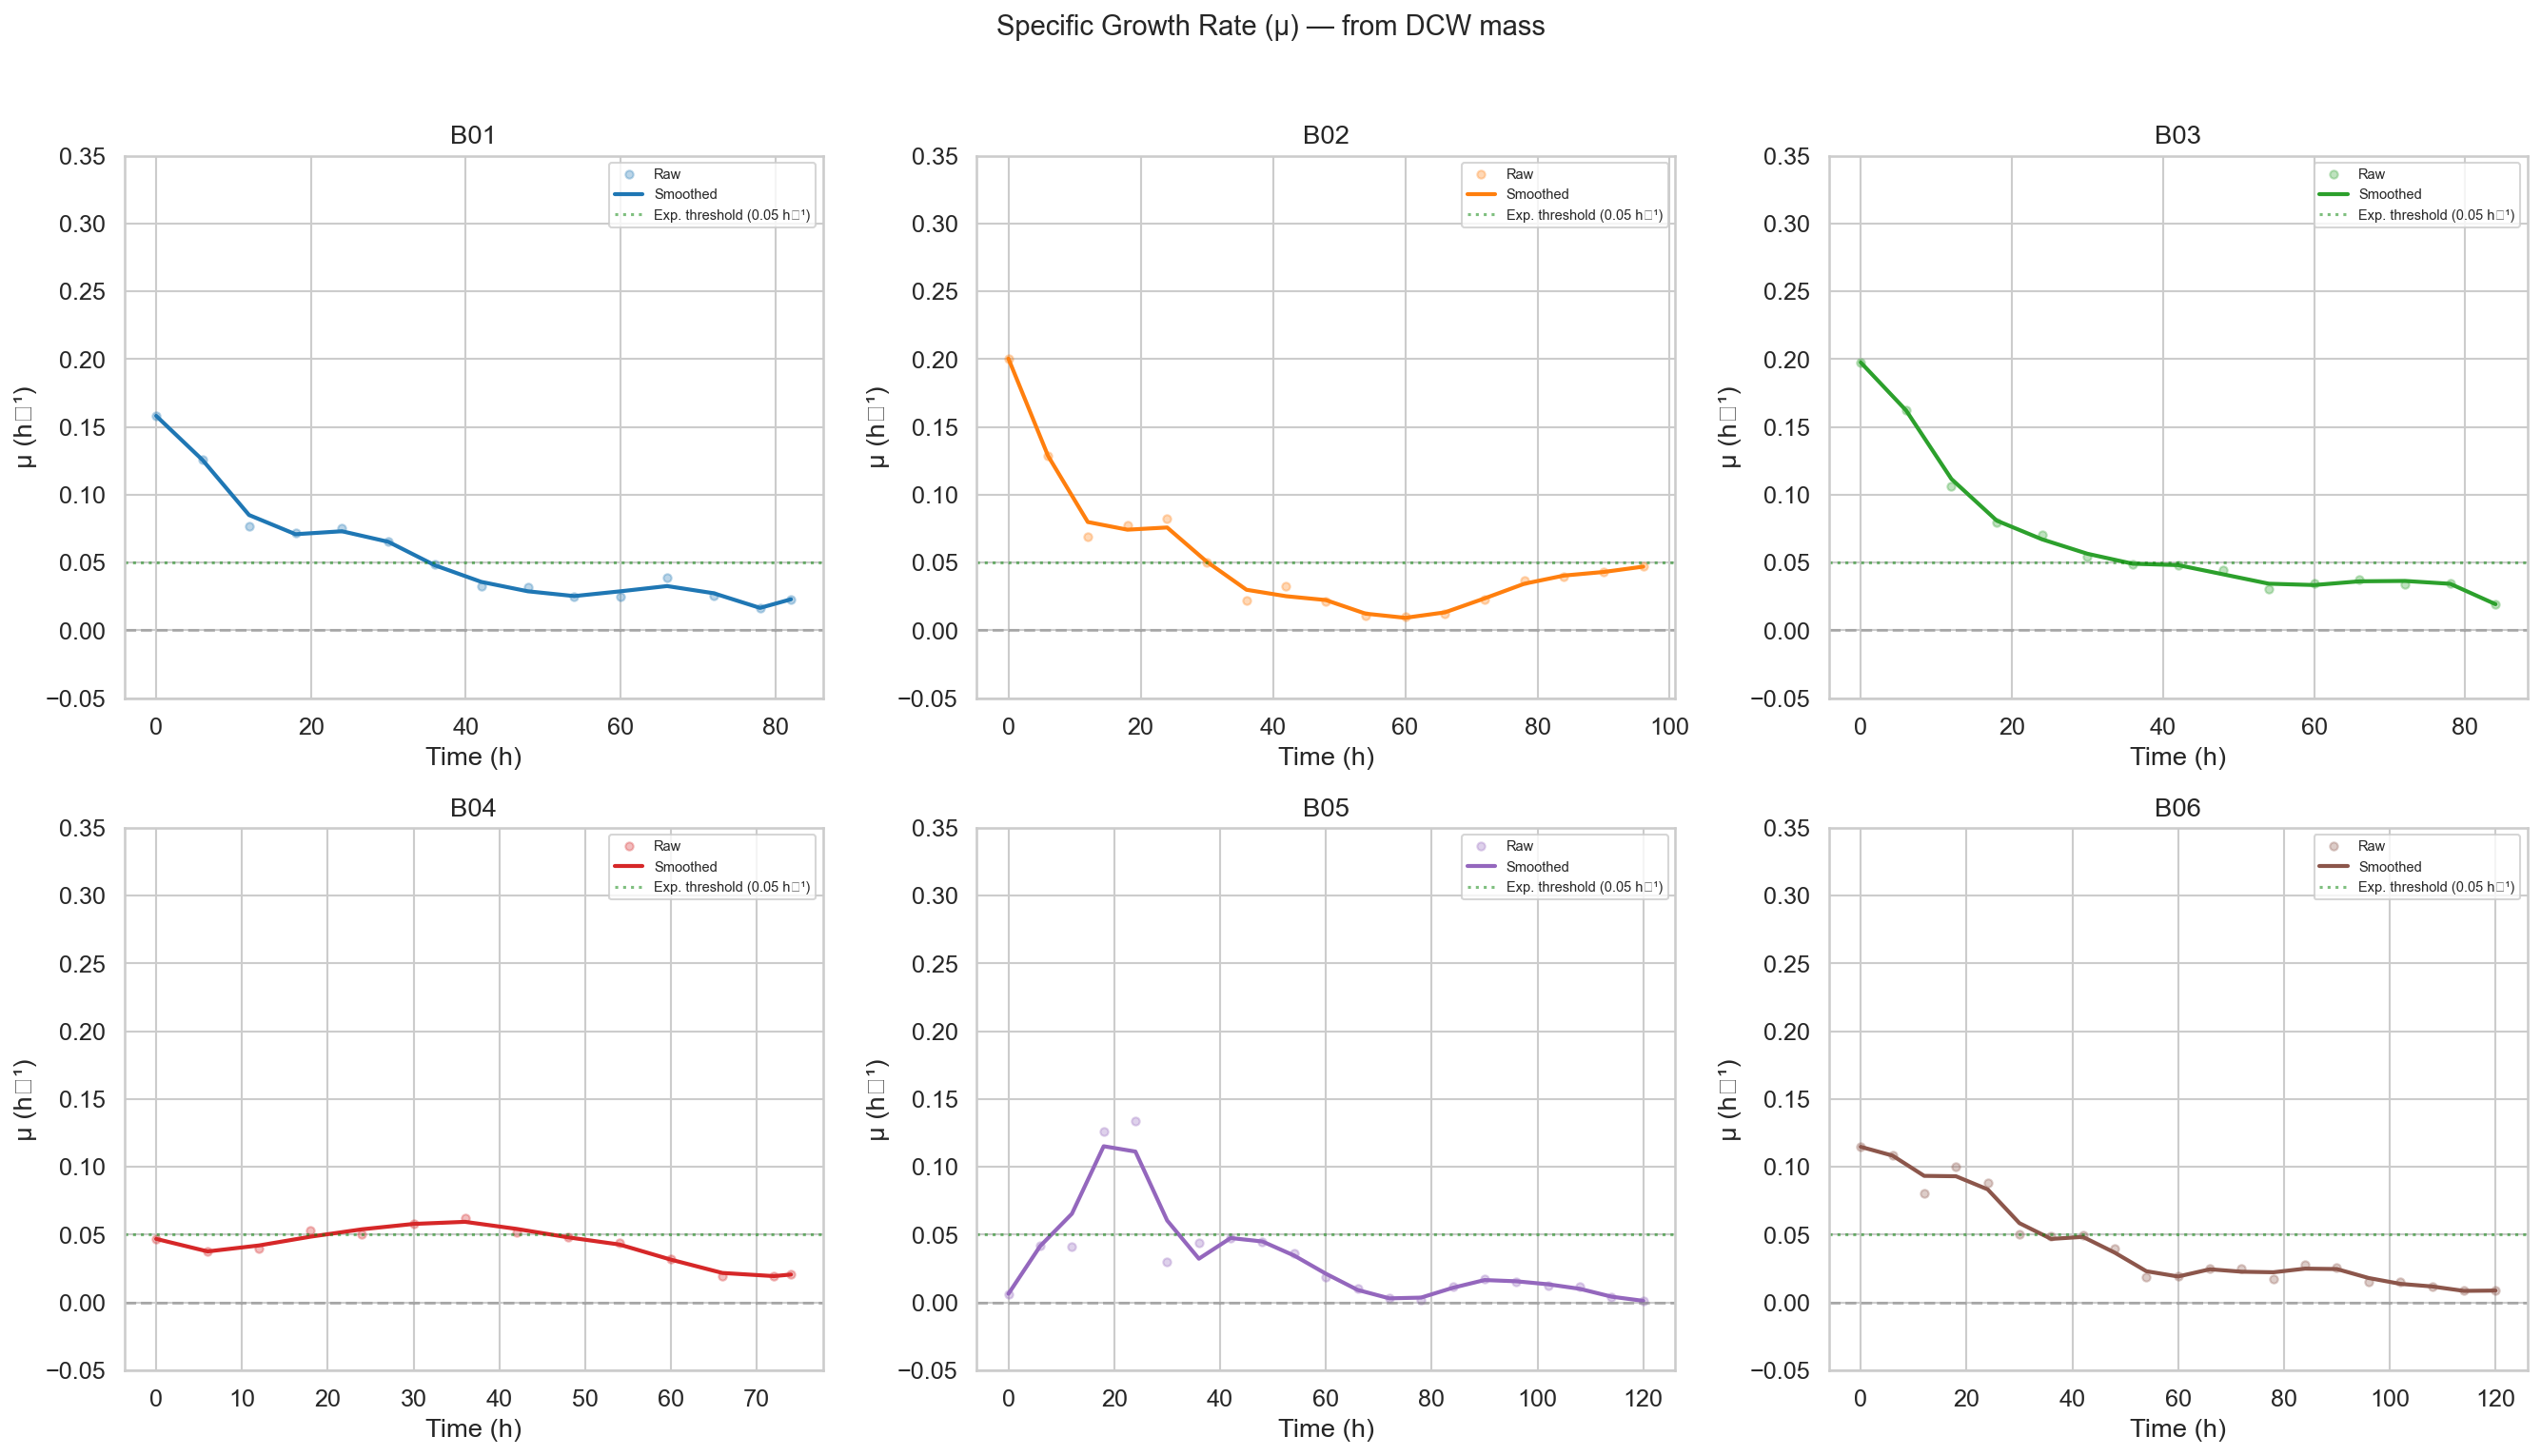

,Batch,mu_max (h⁻¹),Time at mu_max (h),DCW at mu_max (g/L)
0,B01,0.1582,0,1.1
1,B02,0.2003,0,1.0
2,B03,0.1975,0,0.6
3,B04,0.0594,36,43.1
4,B05,0.1152,18,6.9
5,B06,0.1147,0,1.5


In [11]:
# --- Plot 3a: mu over time per batch ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

mu_summary = []
for idx, (b, df) in enumerate(sorted(batches.items())):
    ax = axes[idx // 3][idx % 3]
    
    ax.plot(df['Time_h'], df['mu_raw_h'], 'o', alpha=0.3,
            color=BATCH_COLORS[b], markersize=4, label='Raw')
    ax.plot(df['Time_h'], df['mu_smooth_h'], '-', linewidth=2,
            color=BATCH_COLORS[b], label='Smoothed')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=PARAMS['mu_exponential_threshold'], color='green',
               linestyle=':', alpha=0.5, label=f'Exp. threshold ({PARAMS["mu_exponential_threshold"]} h⁻¹)')
    
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('μ (h⁻¹)')
    ax.set_title(f'{b}')
    ax.set_ylim(-0.05, 0.35)
    ax.legend(fontsize=7)
    
    # Find max mu
    max_idx = df['mu_smooth_h'].idxmax()
    mu_summary.append({
        'Batch': b,
        'mu_max (h⁻¹)': round(df.loc[max_idx, 'mu_smooth_h'], 4),
        'Time at mu_max (h)': df.loc[max_idx, 'Time_h'],
        'DCW at mu_max (g/L)': round(df.loc[max_idx, 'DCW_gL'], 1),
    })

plt.suptitle('Specific Growth Rate (μ) — from DCW mass', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

display(pd.DataFrame(mu_summary))

---
## Analysis 4: pO₂–μ Cross-Correlation

**Key context:** The Critical Oxygen Concentration (C_critical) for *S. cerevisiae* is ~10–15% of air saturation. Below this, the specific oxygen uptake rate drops and metabolism shifts. **DO values above 20% are NOT limiting** — the previous analysis incorrectly flagged these.

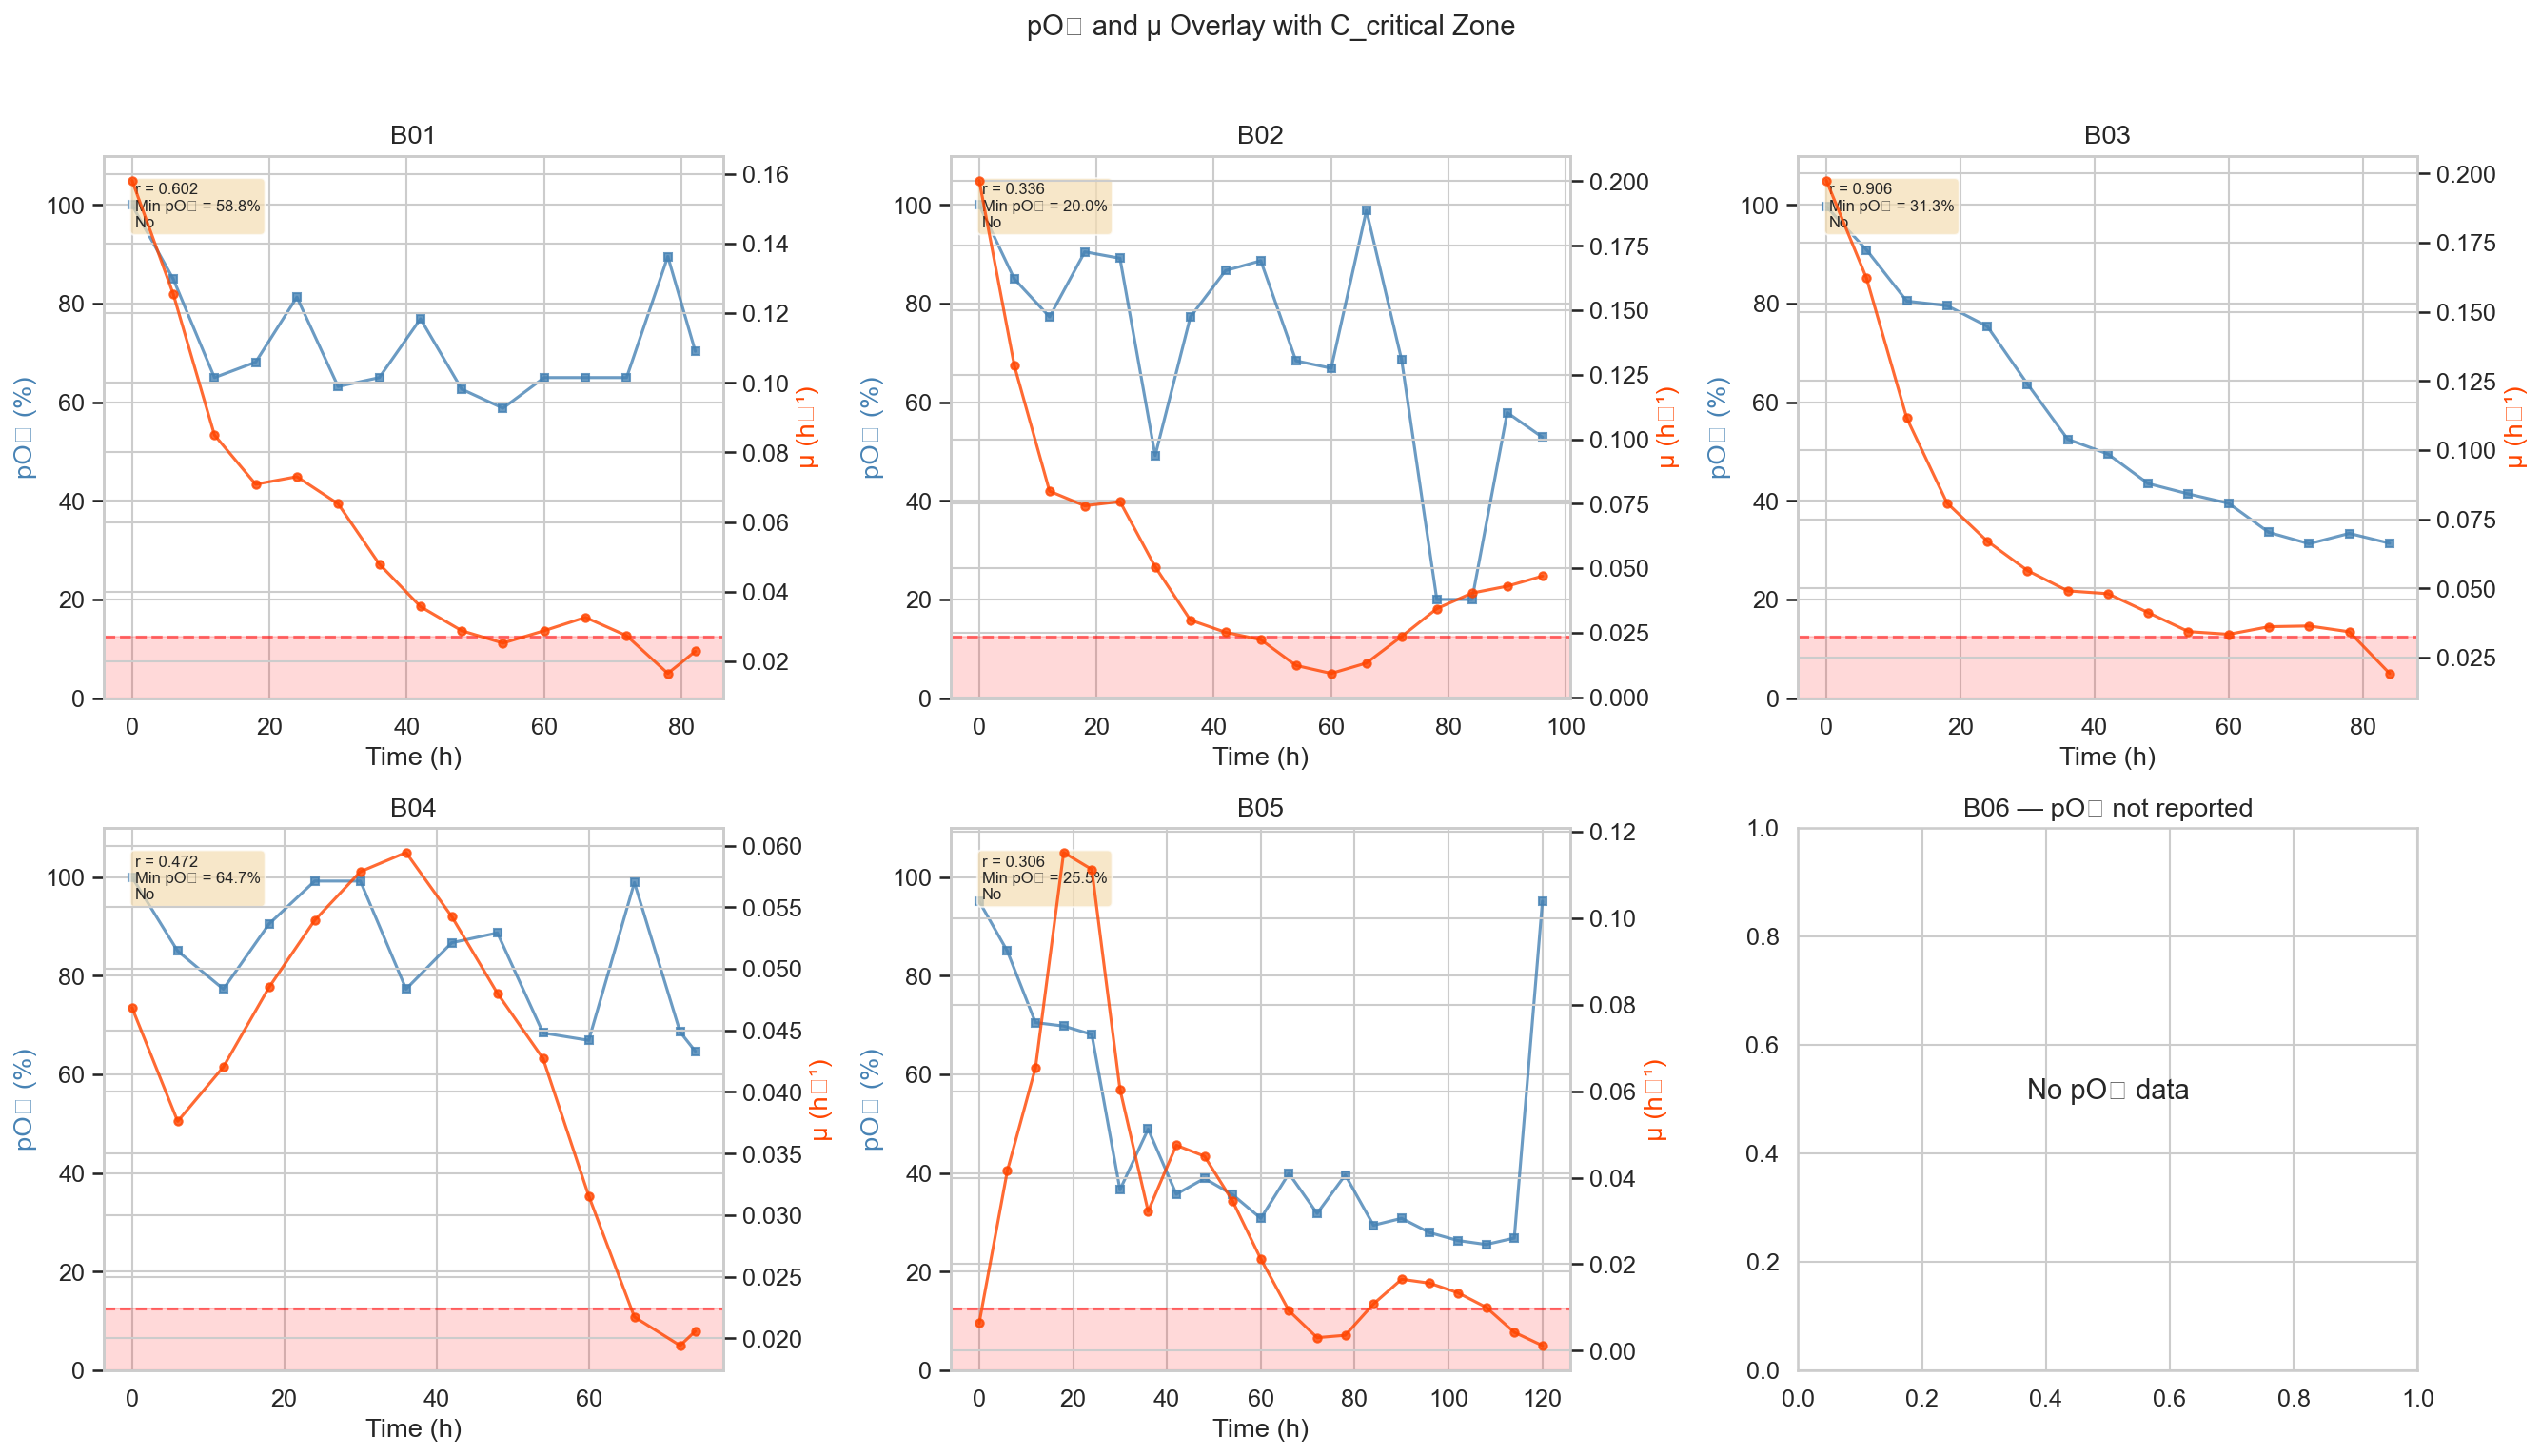

,Batch,Correlation (r),Min pO2 (%),O2 limiting?
0,B01,0.602,58.8,No
1,B02,0.336,20.0,No
2,B03,0.906,31.3,No
3,B04,0.472,64.7,No
4,B05,0.306,25.5,No
5,B06,N/A,N/A,No data


In [12]:
# --- Plot 4: pO2 and mu overlay with C_critical zone ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

corr_summary = []
for idx, (b, df) in enumerate(sorted(batches.items())):
    ax = axes[idx // 3][idx % 3]
    
    if df['pO2_pct'].isna().all():
        ax.text(0.5, 0.5, 'No pO₂ data', transform=ax.transAxes,
                ha='center', fontsize=14)
        ax.set_title(f'{b} — pO₂ not reported')
        corr_summary.append({'Batch': b, 'Correlation (r)': 'N/A',
                             'Min pO2 (%)': 'N/A', 'O2 limiting?': 'No data'})
        continue
    
    # Dual axis
    ax2 = ax.twinx()
    
    ax.plot(df['Time_h'], df['pO2_pct'], 's-', color='steelblue',
            markersize=4, label='pO₂', alpha=0.8)
    ax2.plot(df['Time_h'], df['mu_smooth_h'], 'o-', color='orangered',
             markersize=4, label='μ (smoothed)', alpha=0.8)
    
    # C_critical zone (shaded)
    c_crit = PARAMS['C_critical_pct']
    ax.axhspan(0, c_crit, alpha=0.15, color='red', label=f'C_critical zone (<{c_crit}%)')
    ax.axhline(y=c_crit, color='red', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('pO₂ (%)', color='steelblue')
    ax2.set_ylabel('μ (h⁻¹)', color='orangered')
    ax.set_title(f'{b}')
    ax.set_ylim(0, 110)
    
    # Correlation
    valid = df['pO2_pct'].notna() & df['mu_smooth_h'].notna()
    if valid.sum() > 2:
        corr = np.corrcoef(df.loc[valid, 'pO2_pct'],
                           df.loc[valid, 'mu_smooth_h'])[0, 1]
    else:
        corr = np.nan
    
    min_po2 = df['pO2_pct'].min()
    o2_limiting = 'YES' if min_po2 < c_crit else 'No'
    
    corr_summary.append({
        'Batch': b,
        'Correlation (r)': round(corr, 3) if not np.isnan(corr) else 'N/A',
        'Min pO2 (%)': round(min_po2, 1),
        'O2 limiting?': o2_limiting
    })
    
    ax.text(0.05, 0.95, f'r = {corr:.3f}\nMin pO₂ = {min_po2:.1f}%\n{o2_limiting}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('pO₂ and μ Overlay with C_critical Zone', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

display(pd.DataFrame(corr_summary))

---
## Analysis 5: Carbon Balance Envelope

Compare total glucose input (batch + feed + pulses) against actual biomass produced.  
Theoretical max biomass = total_glucose × Yx/s (0.45 g/g).  
The gap reveals carbon lost to CO₂, ethanol, maintenance, and product.

In [13]:
# --- Carbon balance per batch ---
carbon_results = []
for b, df in sorted(batches.items()):
    result = compute_carbon_balance(df, metadata, PARAMS)
    carbon_results.append(result)

carbon_df = pd.DataFrame(carbon_results)
display(carbon_df)

,batch,batch_glucose_g,fed_glucose_g,pulse_glucose_g,total_glucose_g,dcw_initial_g,dcw_final_g,delta_dcw_g,theoretical_max_dcw_g,yield_fraction
0,B01,30.0,912.50,0.0,942.50,1.75,147.77,146.02,424.12,0.344
1,B02,30.0,1350.19,0.0,1380.19,1.64,177.80,176.16,621.09,0.284
2,B03,30.0,969.85,0.0,999.85,0.96,204.42,203.46,449.93,0.452
3,B04,30.0,917.91,50.0,997.91,14.73,364.95,350.22,449.06,0.780
4,B05,30.0,1222.02,0.0,1252.02,6.53,332.76,326.23,563.41,0.579
5,B06,30.0,1495.44,45.0,1570.44,2.39,363.87,361.49,706.70,0.512


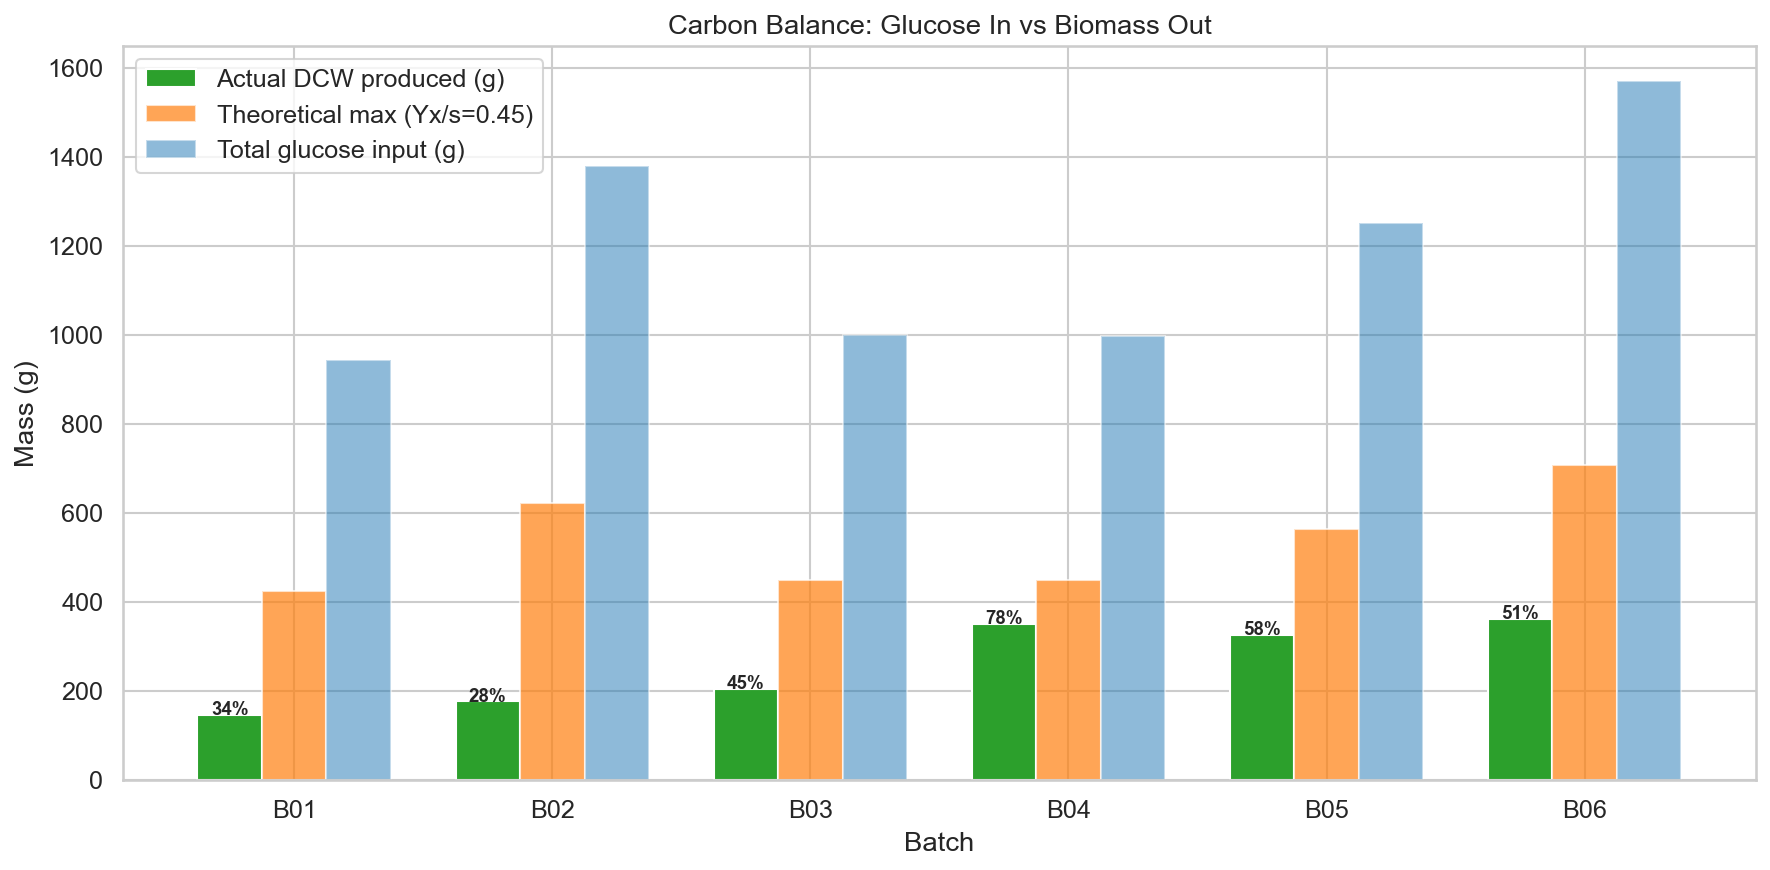

In [14]:
# --- Plot 5: Carbon balance bar chart ---
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(carbon_df))
width = 0.25

ax.bar(x - width, carbon_df['delta_dcw_g'], width,
       label='Actual DCW produced (g)', color='#2ca02c')
ax.bar(x, carbon_df['theoretical_max_dcw_g'], width,
       label=f'Theoretical max (Yx/s={PARAMS["Yxs"]})', color='#ff7f0e', alpha=0.7)
ax.bar(x + width, carbon_df['total_glucose_g'], width,
       label='Total glucose input (g)', color='#1f77b4', alpha=0.5)

ax.set_xlabel('Batch')
ax.set_ylabel('Mass (g)')
ax.set_title('Carbon Balance: Glucose In vs Biomass Out')
ax.set_xticks(x)
ax.set_xticklabels(carbon_df['batch'])
ax.legend()

# Annotate yield fractions
for i, row in carbon_df.iterrows():
    ax.text(i - width, row['delta_dcw_g'] + 1,
            f"{row['yield_fraction']:.0%}",
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Analysis 6: Specific Glucose Feed Rate & Crabtree Risk

The **Crabtree Effect** in *S. cerevisiae*: when glucose is present above ~0.1 g/L (or equivalently, when the specific glucose uptake rate exceeds a critical threshold), cells produce ethanol even under aerobic conditions, wasting carbon and generating toxic byproducts.

**Two complementary indicators:**

1. **Specific glucose feed rate (qs)** = (feed_rate × [glucose_feed]) / total_DCW_mass  
   Critical qs for *S. cerevisiae*: ~0.20–0.30 g glucose / g DCW / h  
   *Refs: Postma et al. (1989) Appl Environ Microbiol; Van Hoek et al. (1998) Biotechnol Bioeng*

2. **Glucose surplus (mass balance)** — cumulative glucose fed minus glucose accounted for by biomass production (ΔDCW / Yx/s). This surplus represents carbon diverted to CO₂, ethanol, maintenance, and product.  
   **Note:** This is NOT the actual residual glucose in the fermenter — it is the glucose *unaccounted for by biomass alone*. Without ethanol/CO₂ measurements, we cannot determine the true residual glucose.

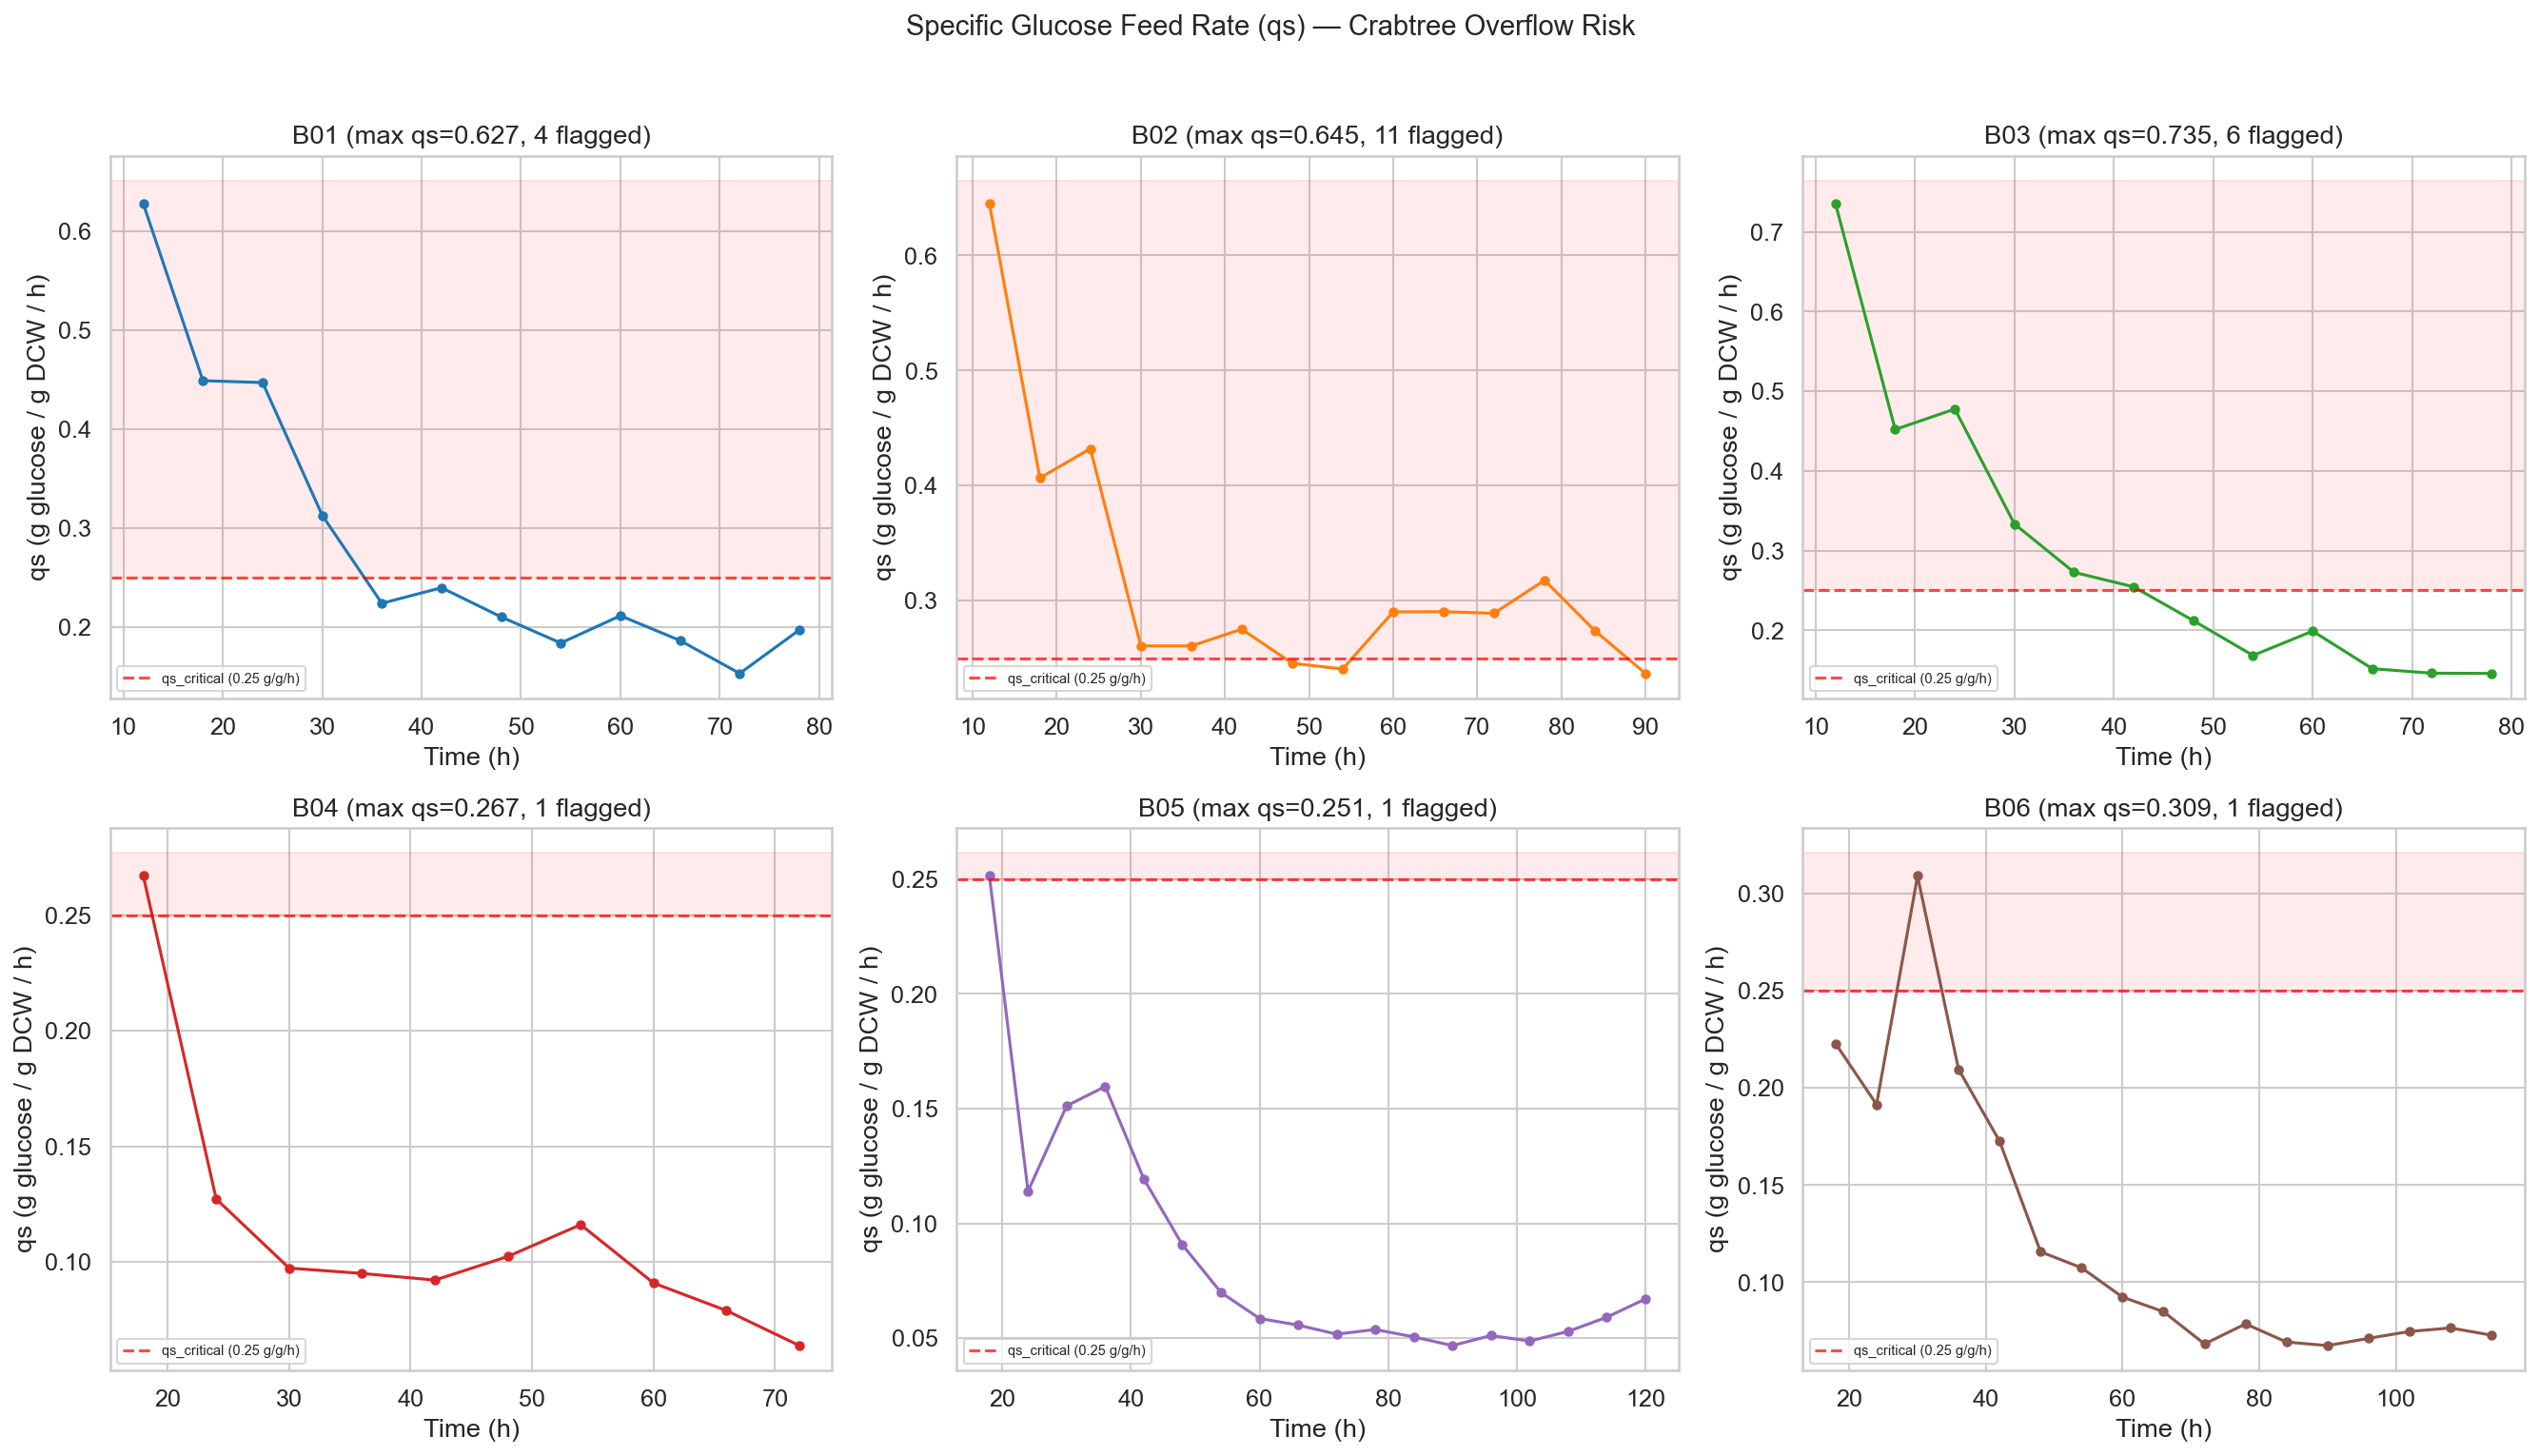

,Batch,Max qs (g/g/h),Time at max qs (h),Points above qs_crit,Overflow risk
0,B01,0.6273,12,4,YES
1,B02,0.6447,12,11,YES
2,B03,0.7352,12,6,YES
3,B04,0.2670,18,1,YES
4,B05,0.2514,18,1,YES
5,B06,0.3090,30,1,YES


In [15]:
# --- Plot 6a: Specific glucose feed rate (qs) with Crabtree threshold ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
qs_crit = PARAMS.get('qs_critical_ggh', 0.25)

qs_summary = []
for idx, (b, df) in enumerate(sorted(batches.items())):
    ax = axes[idx // 3][idx % 3]
    
    # Plot qs trajectory
    valid = df['qs_ggh'].notna() & (df['qs_ggh'] > 0)
    ax.plot(df.loc[valid, 'Time_h'], df.loc[valid, 'qs_ggh'], 'o-',
            color=BATCH_COLORS[b], markersize=4)
    
    # Crabtree threshold line
    ax.axhline(y=qs_crit, color='red', linestyle='--', alpha=0.7,
               label=f'qs_critical ({qs_crit} g/g/h)')
    
    # Shade region above threshold
    ax.axhspan(qs_crit, ax.get_ylim()[1] if ax.get_ylim()[1] > qs_crit else qs_crit * 3,
               alpha=0.08, color='red')
    
    n_flagged = df['Crabtree_qs_Flag'].sum()
    max_qs = df['qs_ggh'].max()
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('qs (g glucose / g DCW / h)')
    ax.set_title(f'{b} (max qs={max_qs:.3f}, {n_flagged} flagged)')
    ax.legend(fontsize=7)
    
    qs_summary.append({
        'Batch': b,
        'Max qs (g/g/h)': round(max_qs, 4) if not np.isnan(max_qs) else 'N/A',
        'Time at max qs (h)': df.loc[df['qs_ggh'].idxmax(), 'Time_h'] if not np.isnan(max_qs) else 'N/A',
        'Points above qs_crit': n_flagged,
        'Overflow risk': 'YES' if n_flagged > 0 else 'Low'
    })

plt.suptitle('Specific Glucose Feed Rate (qs) — Crabtree Overflow Risk', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

display(pd.DataFrame(qs_summary))

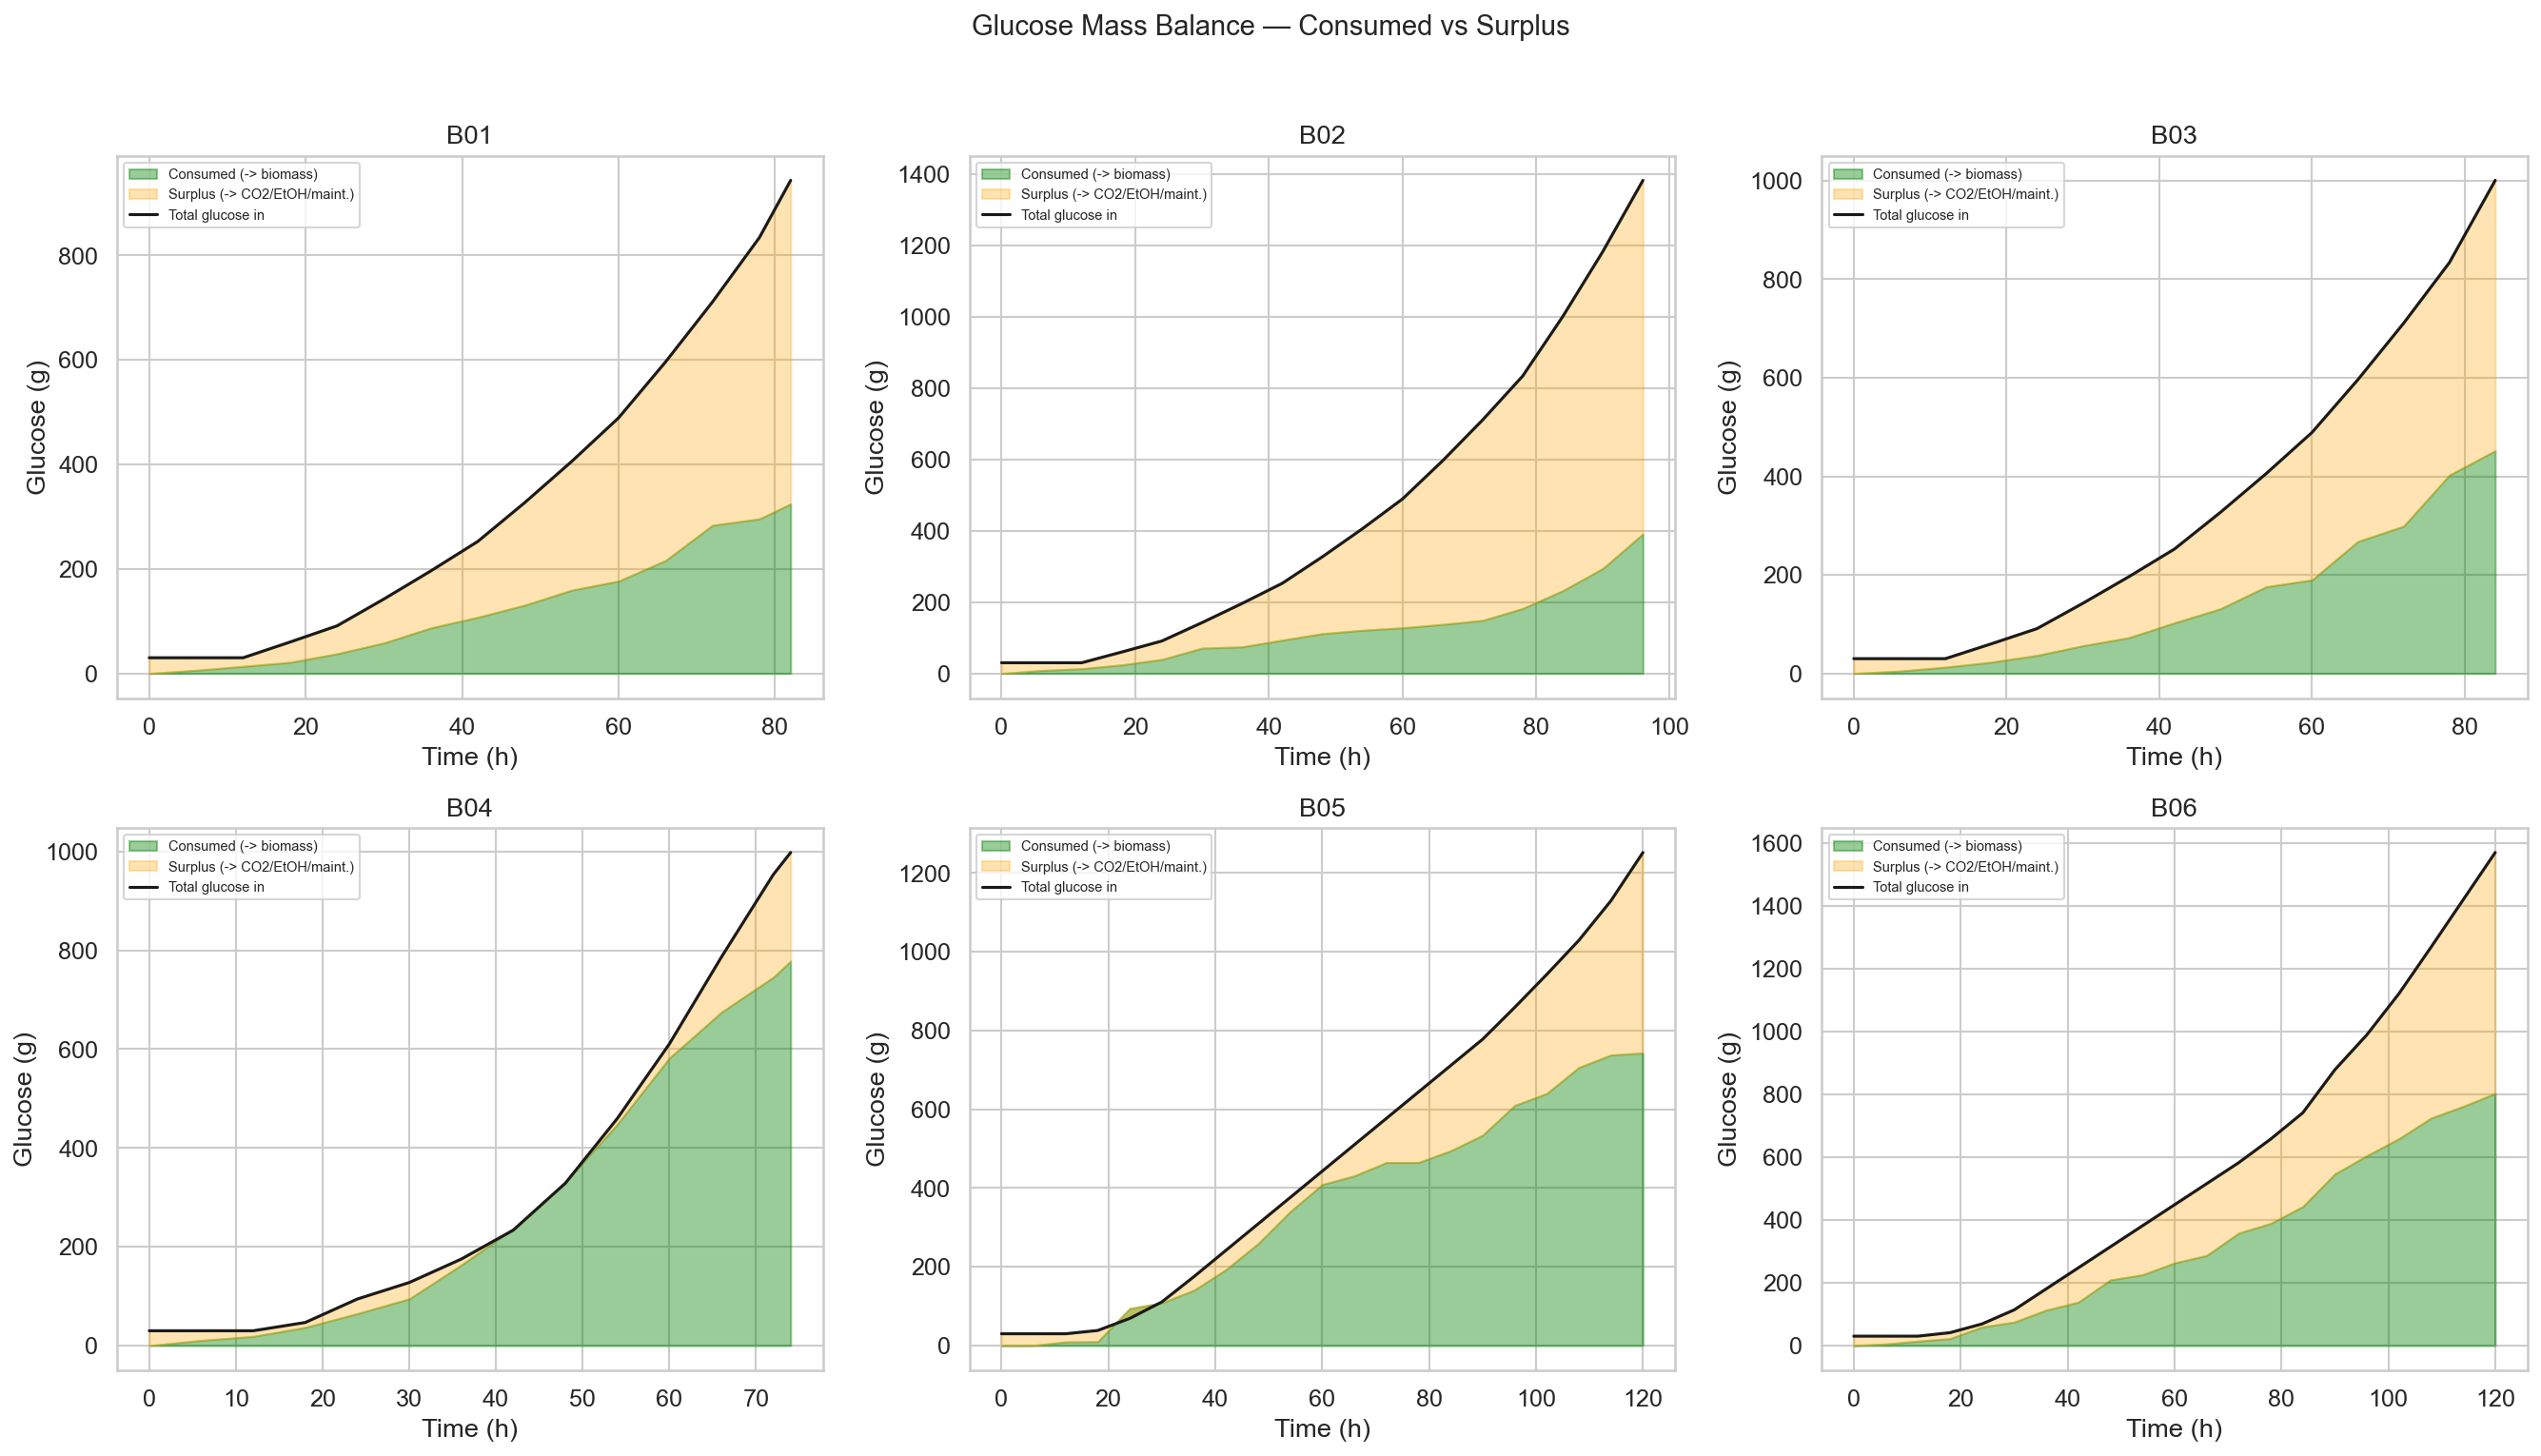

In [16]:
# --- Plot 6b: Glucose mass balance surplus (cumulative) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (b, df) in enumerate(sorted(batches.items())):
    ax = axes[idx // 3][idx % 3]
    
    t = df['Time_h']
    # Use V_batch_medium_mL (not Scale_L) for initial glucose — inoculum has no glucose
    V_batch_L = PARAMS['V_batch_medium_mL'][b] / 1000.0
    glucose_batch = PARAMS['glucose_conc_batch_gL'] * V_batch_L
    total_in = glucose_batch + df['Cumul_Glucose_Fed_g']
    consumed = df['Cumul_Glucose_Consumed_g']
    surplus = total_in - consumed
    
    ax.fill_between(t, 0, consumed, alpha=0.4, color='green', label='Consumed (-> biomass)')
    ax.fill_between(t, consumed, total_in, alpha=0.3, color='orange',
                    label='Surplus (-> CO2/EtOH/maint.)')
    ax.plot(t, total_in, 'k-', linewidth=1.5, label='Total glucose in')
    
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Glucose (g)')
    ax.set_title(f'{b}')
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Glucose Mass Balance — Consumed vs Surplus', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Analysis 7: OD/WCW Ratio Trajectory

The OD600-to-WCW ratio is a proxy for cell size and composition:  
- **Declining ratio** → cells getting heavier per unit optical density (lipid accumulation, vacuolation, larger cells)  
- **Increasing ratio** → cell fragmentation or lysis (debris scatters light but doesn't pellet)

**Important:** B01–B03 (Hitachi spectrophotometer) and B04–B06 (LABMAN) use different instruments, so absolute ratio values are not directly comparable between equipment groups.

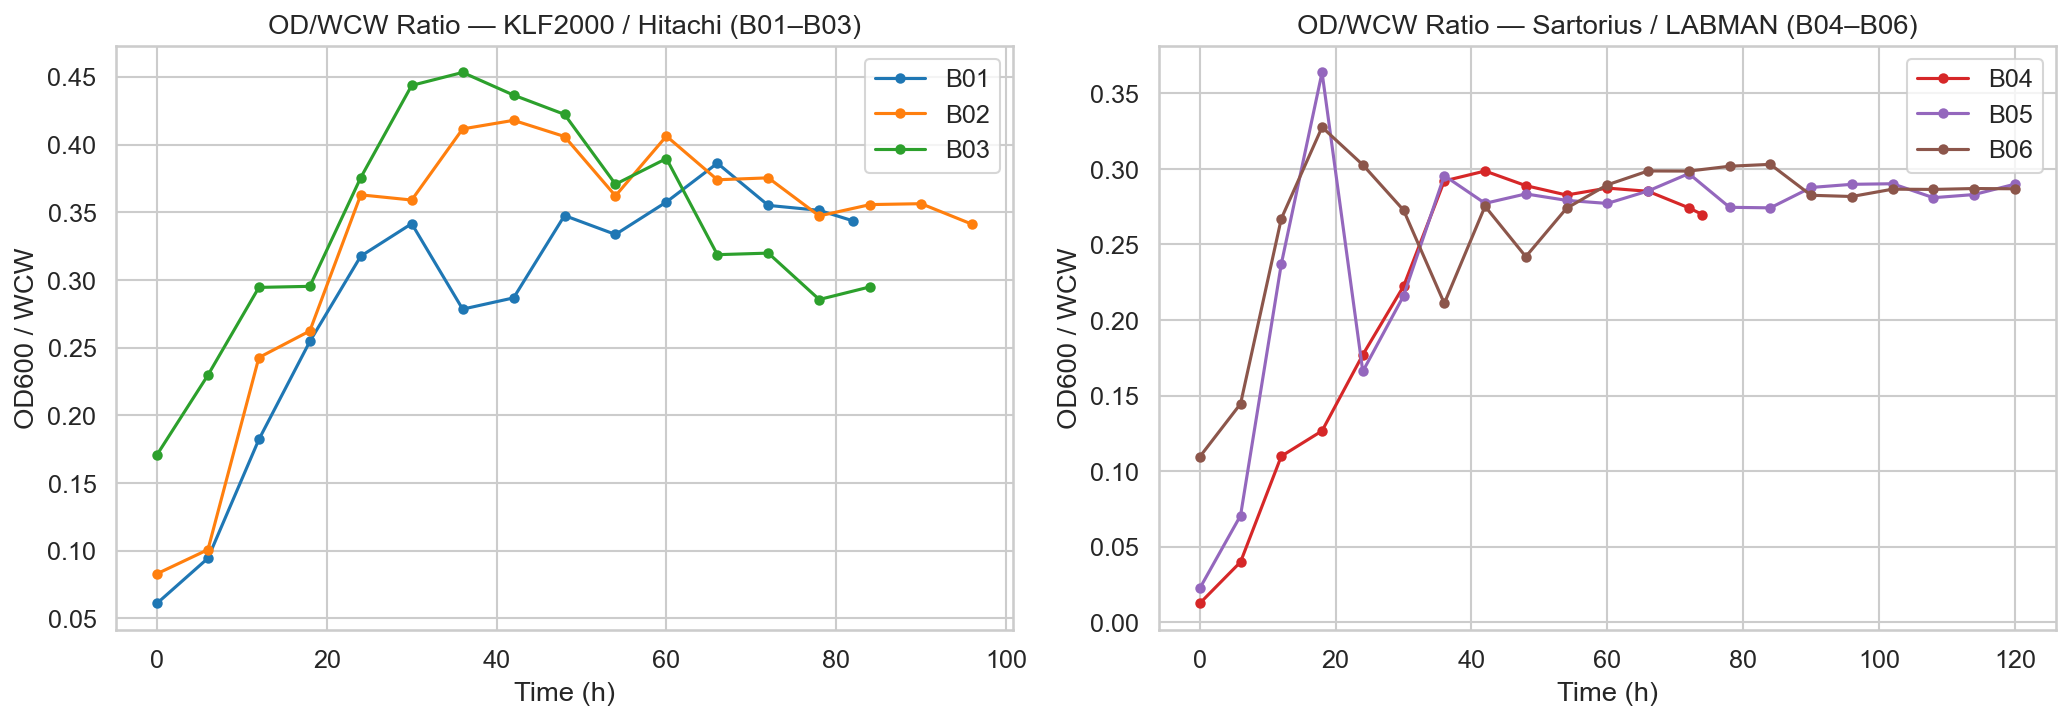

In [17]:
# --- Plot 7: OD/WCW ratio over time ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# B01-B03 (KLF2000 / Hitachi)
ax = axes[0]
for b in ['B01', 'B02', 'B03']:
    df = batches[b]
    ax.plot(df['Time_h'], df['OD_WCW_ratio'], 'o-', label=b,
            color=BATCH_COLORS[b], markersize=4)
ax.set_xlabel('Time (h)')
ax.set_ylabel('OD600 / WCW')
ax.set_title('OD/WCW Ratio — KLF2000 / Hitachi (B01–B03)')
ax.legend()

# B04-B06 (Sartorius / LABMAN)
ax = axes[1]
for b in ['B04', 'B05', 'B06']:
    df = batches[b]
    ax.plot(df['Time_h'], df['OD_WCW_ratio'], 'o-', label=b,
            color=BATCH_COLORS[b], markersize=4)
ax.set_xlabel('Time (h)')
ax.set_ylabel('OD600 / WCW')
ax.set_title('OD/WCW Ratio — Sartorius / LABMAN (B04–B06)')
ax.legend()

plt.tight_layout()
plt.show()

---
## Analysis 8: kLa Estimates and Oxygen Transfer Assessment

**Approach — Pirt equation for OUR:**

A cell's oxygen demand has two components (Pirt, 1965):

**OUR = (μ / Y<sub>X/O₂,max</sub> + m<sub>O₂</sub>) × X**

| Term | Meaning | Units |
|---|---|---|
| μ / Y<sub>X/O₂,max</sub> | Growth-associated O₂ demand | mmol O₂ / g DCW / h |
| m<sub>O₂</sub> | Maintenance O₂ demand | mmol O₂ / g DCW / h |
| X | Biomass concentration | g DCW / L |
| OUR | Volumetric O₂ uptake rate | mmol O₂ / L / h |

**Unit conversion for Y<sub>X/O₂,max</sub>:**  
Literature reports Y<sub>X/O₂</sub> = 1.0–1.5 g DCW / g O₂.  
Since 1 g O₂ = 31.25 mmol → Y<sub>X/O₂,max</sub> = 1.25 / 31.25 = **0.04 g DCW / mmol O₂**

**Why this matters:** The old formula (OUR = μ×X / Y<sub>X/O₂</sub>) predicts OUR → 0 when μ → 0 (stationary phase). In reality, cells still consume oxygen for maintenance — membrane potential, protein turnover, redox balance. The Pirt equation correctly captures this basal O₂ demand, which is especially significant for B05/B06 where cells spent 60+ hours at very low growth rates.

**kLa from steady-state balance:**  
kLa = OUR / (C* − C<sub>L</sub>), where C* = 7.3 mg/L and C<sub>L</sub> = pO₂/100 × C*

**Sensitivity analysis** on Y<sub>X/O₂</sub> (1.0, 1.25, 1.5 g/g) to capture the range across growth phases.

**References:**  
1. Pirt, S. J. (1965). The maintenance energy of bacteria in growing cultures. *Proc. R. Soc. Lond. B* 163, 224–231.  
2. Verduyn, C., et al. (1991). Energetics of *S. cerevisiae* in anaerobic and aerobic glucose-limited chemostat cultures.  
3. Van den Berg, J. J., et al. (2013). Kinetics and stoichiometry of *S. cerevisiae* growth.  
4. Sonnleitner, B., & Käppeli, O. (1986). Growth of *S. cerevisiae* is controlled by its limited respiratory capacity. *Biotechnol. Bioeng.* 28.  
5. Heijnen, J. J., & Van Dijken, J. P. (1992). In search of a thermodynamic description of biomass yields.  
6. Atkinson, B., & Mavituna, F. (1991). *Biochemical Engineering and Biotechnology Handbook.*

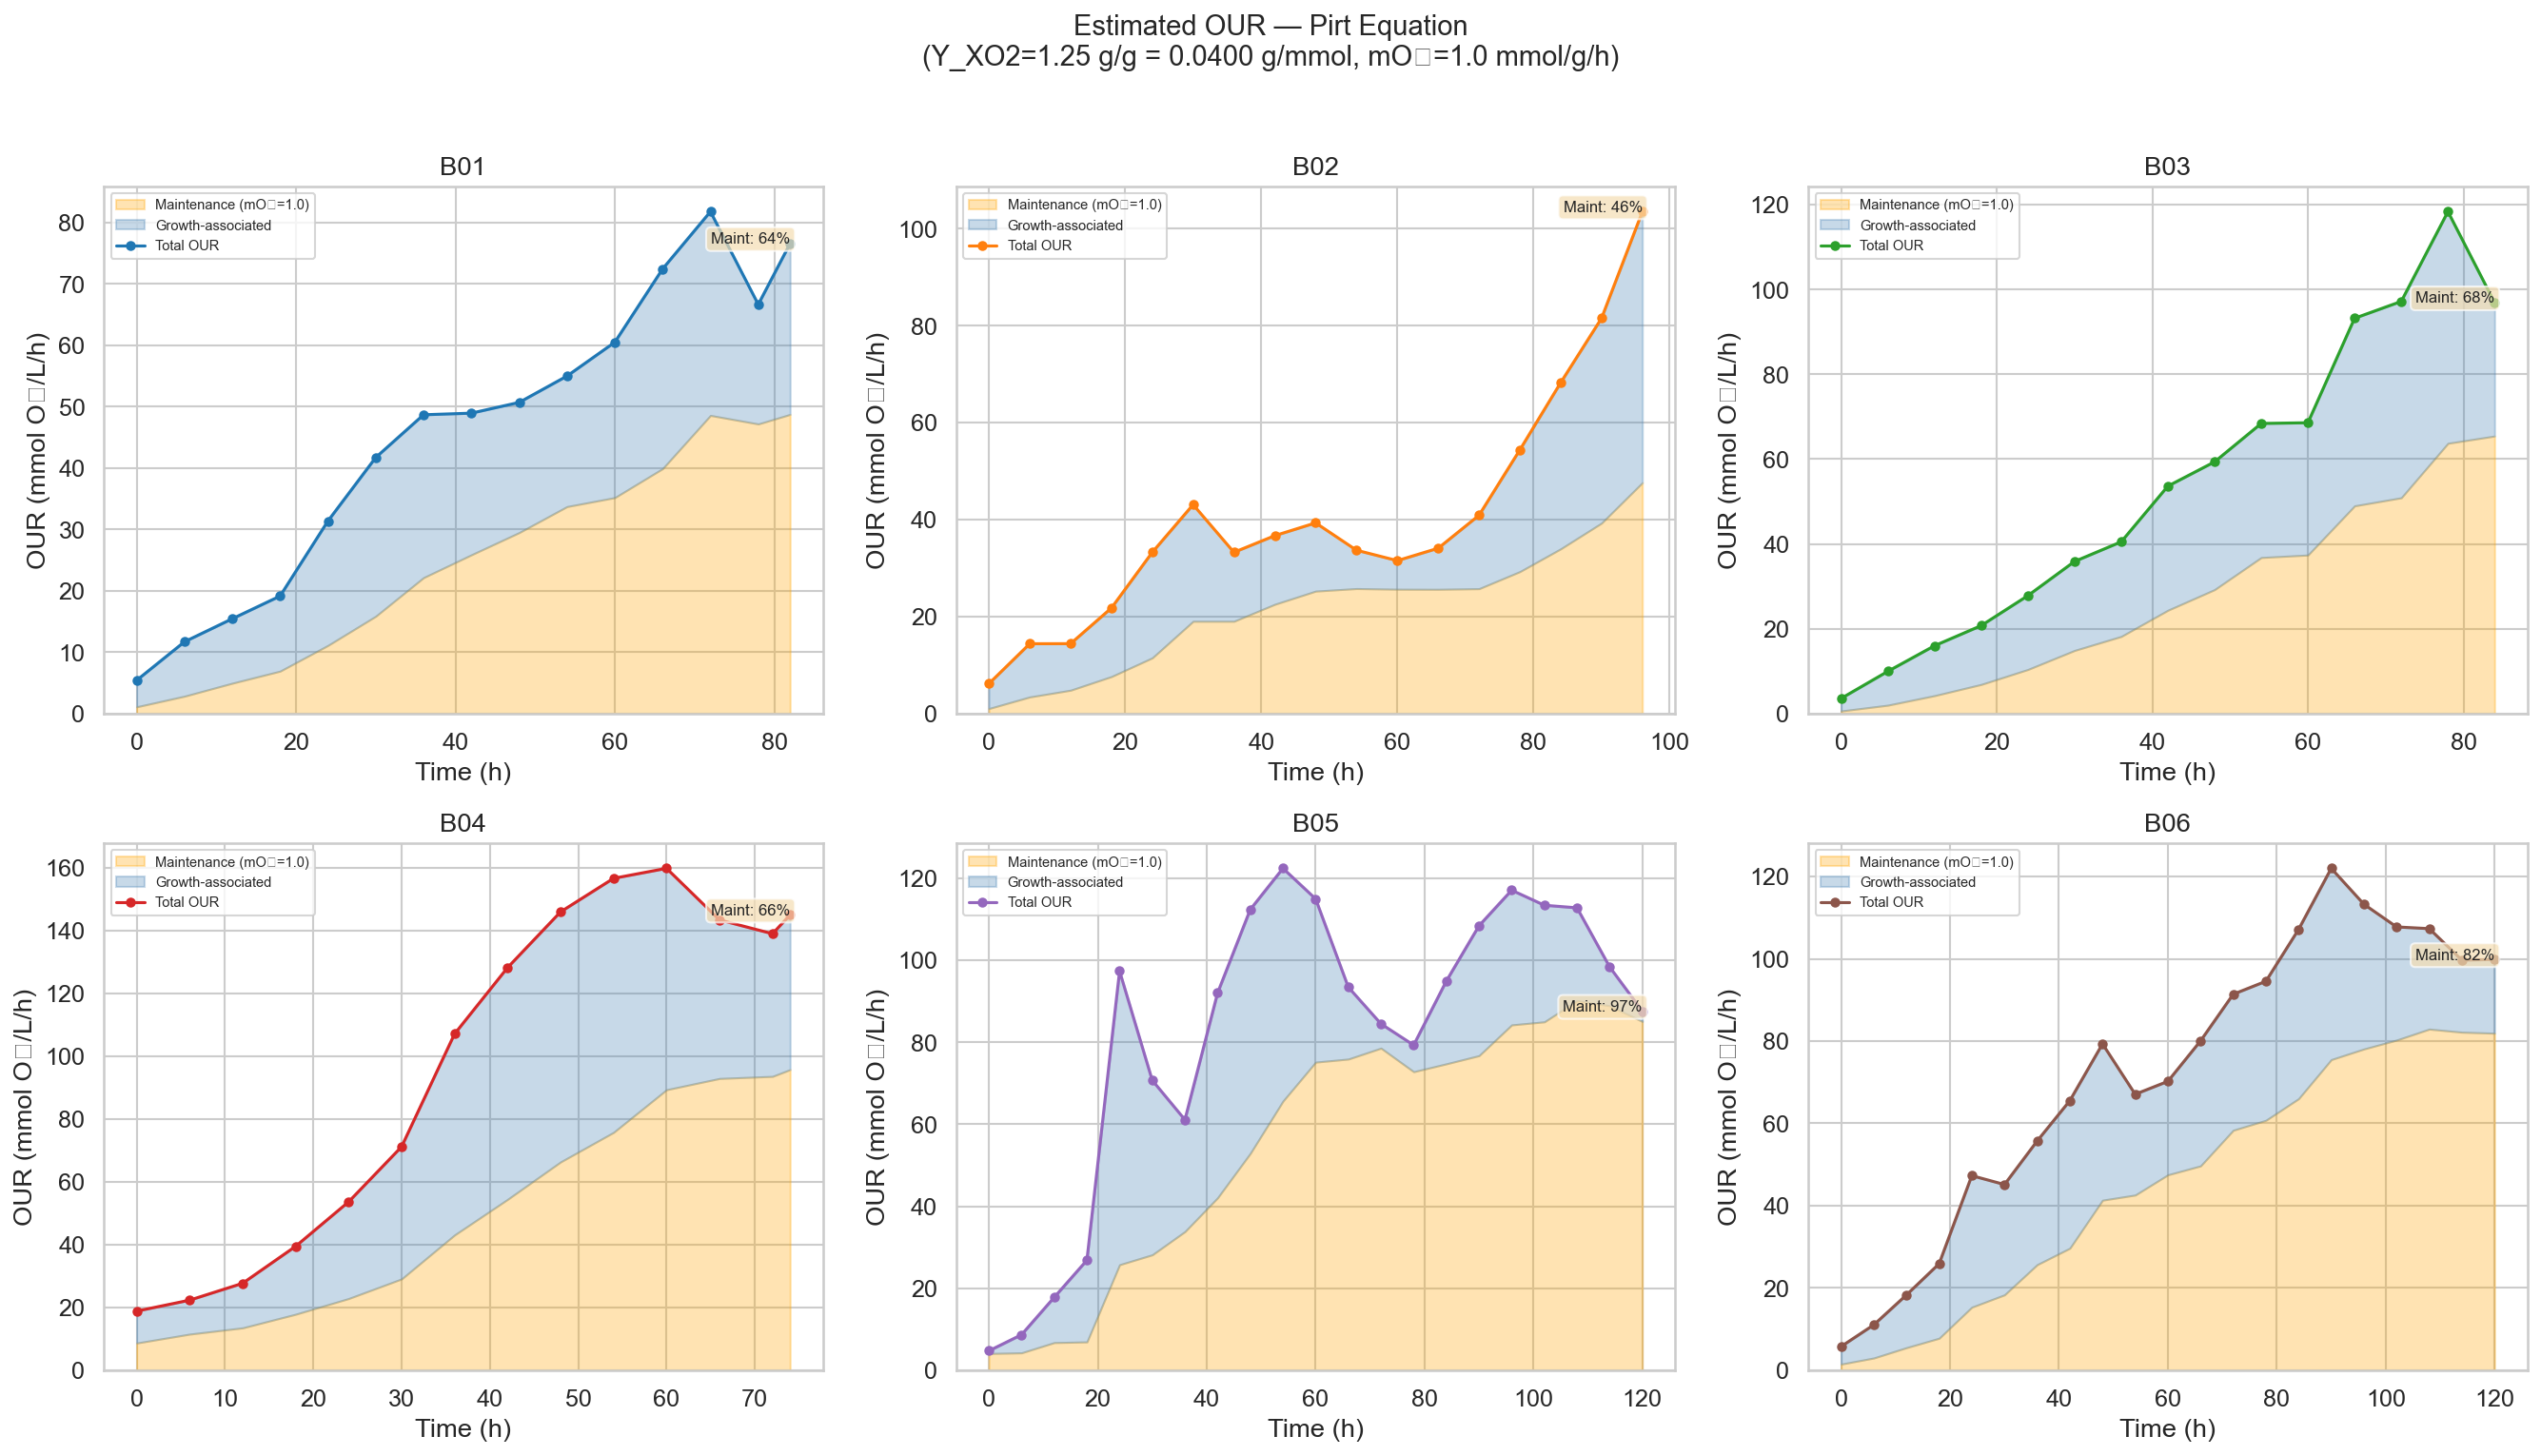

In [18]:
# --- Plot 8a: OUR over time — decomposed into growth vs maintenance ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

mO2_val = PARAMS.get('mO2_mmol_gDCW_h', 1.0)
Y_XO2_val = PARAMS.get('Y_XO2', 1.25)
Y_XO2_mmol = Y_XO2_val / 31.25  # g/mmol

for idx, (b, df) in enumerate(sorted(batches.items())):
    ax = axes[idx // 3][idx % 3]
    
    t = df['Time_h']
    our_total = df['OUR_mmol_L_h']
    our_growth = df['OUR_growth_mmol_L_h']
    our_maint = df['OUR_maint_mmol_L_h']
    
    # Stacked area: maintenance (bottom) + growth (top)
    ax.fill_between(t, 0, our_maint, alpha=0.3, color='orange',
                    label=f'Maintenance (mO₂={mO2_val})')
    ax.fill_between(t, our_maint, our_total, alpha=0.3, color='steelblue',
                    label='Growth-associated')
    ax.plot(t, our_total, 'o-', color=BATCH_COLORS[b], markersize=4,
            linewidth=1.5, label='Total OUR')
    
    # Annotate maintenance fraction at last timepoint
    if our_total.iloc[-1] > 0:
        maint_frac = our_maint.iloc[-1] / our_total.iloc[-1] * 100
        ax.annotate(f'Maint: {maint_frac:.0f}%',
                    xy=(t.iloc[-1], our_total.iloc[-1]),
                    fontsize=8, ha='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('OUR (mmol O₂/L/h)')
    ax.set_title(f'{b}')
    ax.legend(fontsize=7, loc='upper left')
    ax.set_ylim(bottom=0)

plt.suptitle(f'Estimated OUR — Pirt Equation\n'
             f'(Y_XO2={Y_XO2_val} g/g = {Y_XO2_mmol:.4f} g/mmol, mO₂={mO2_val} mmol/g/h)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

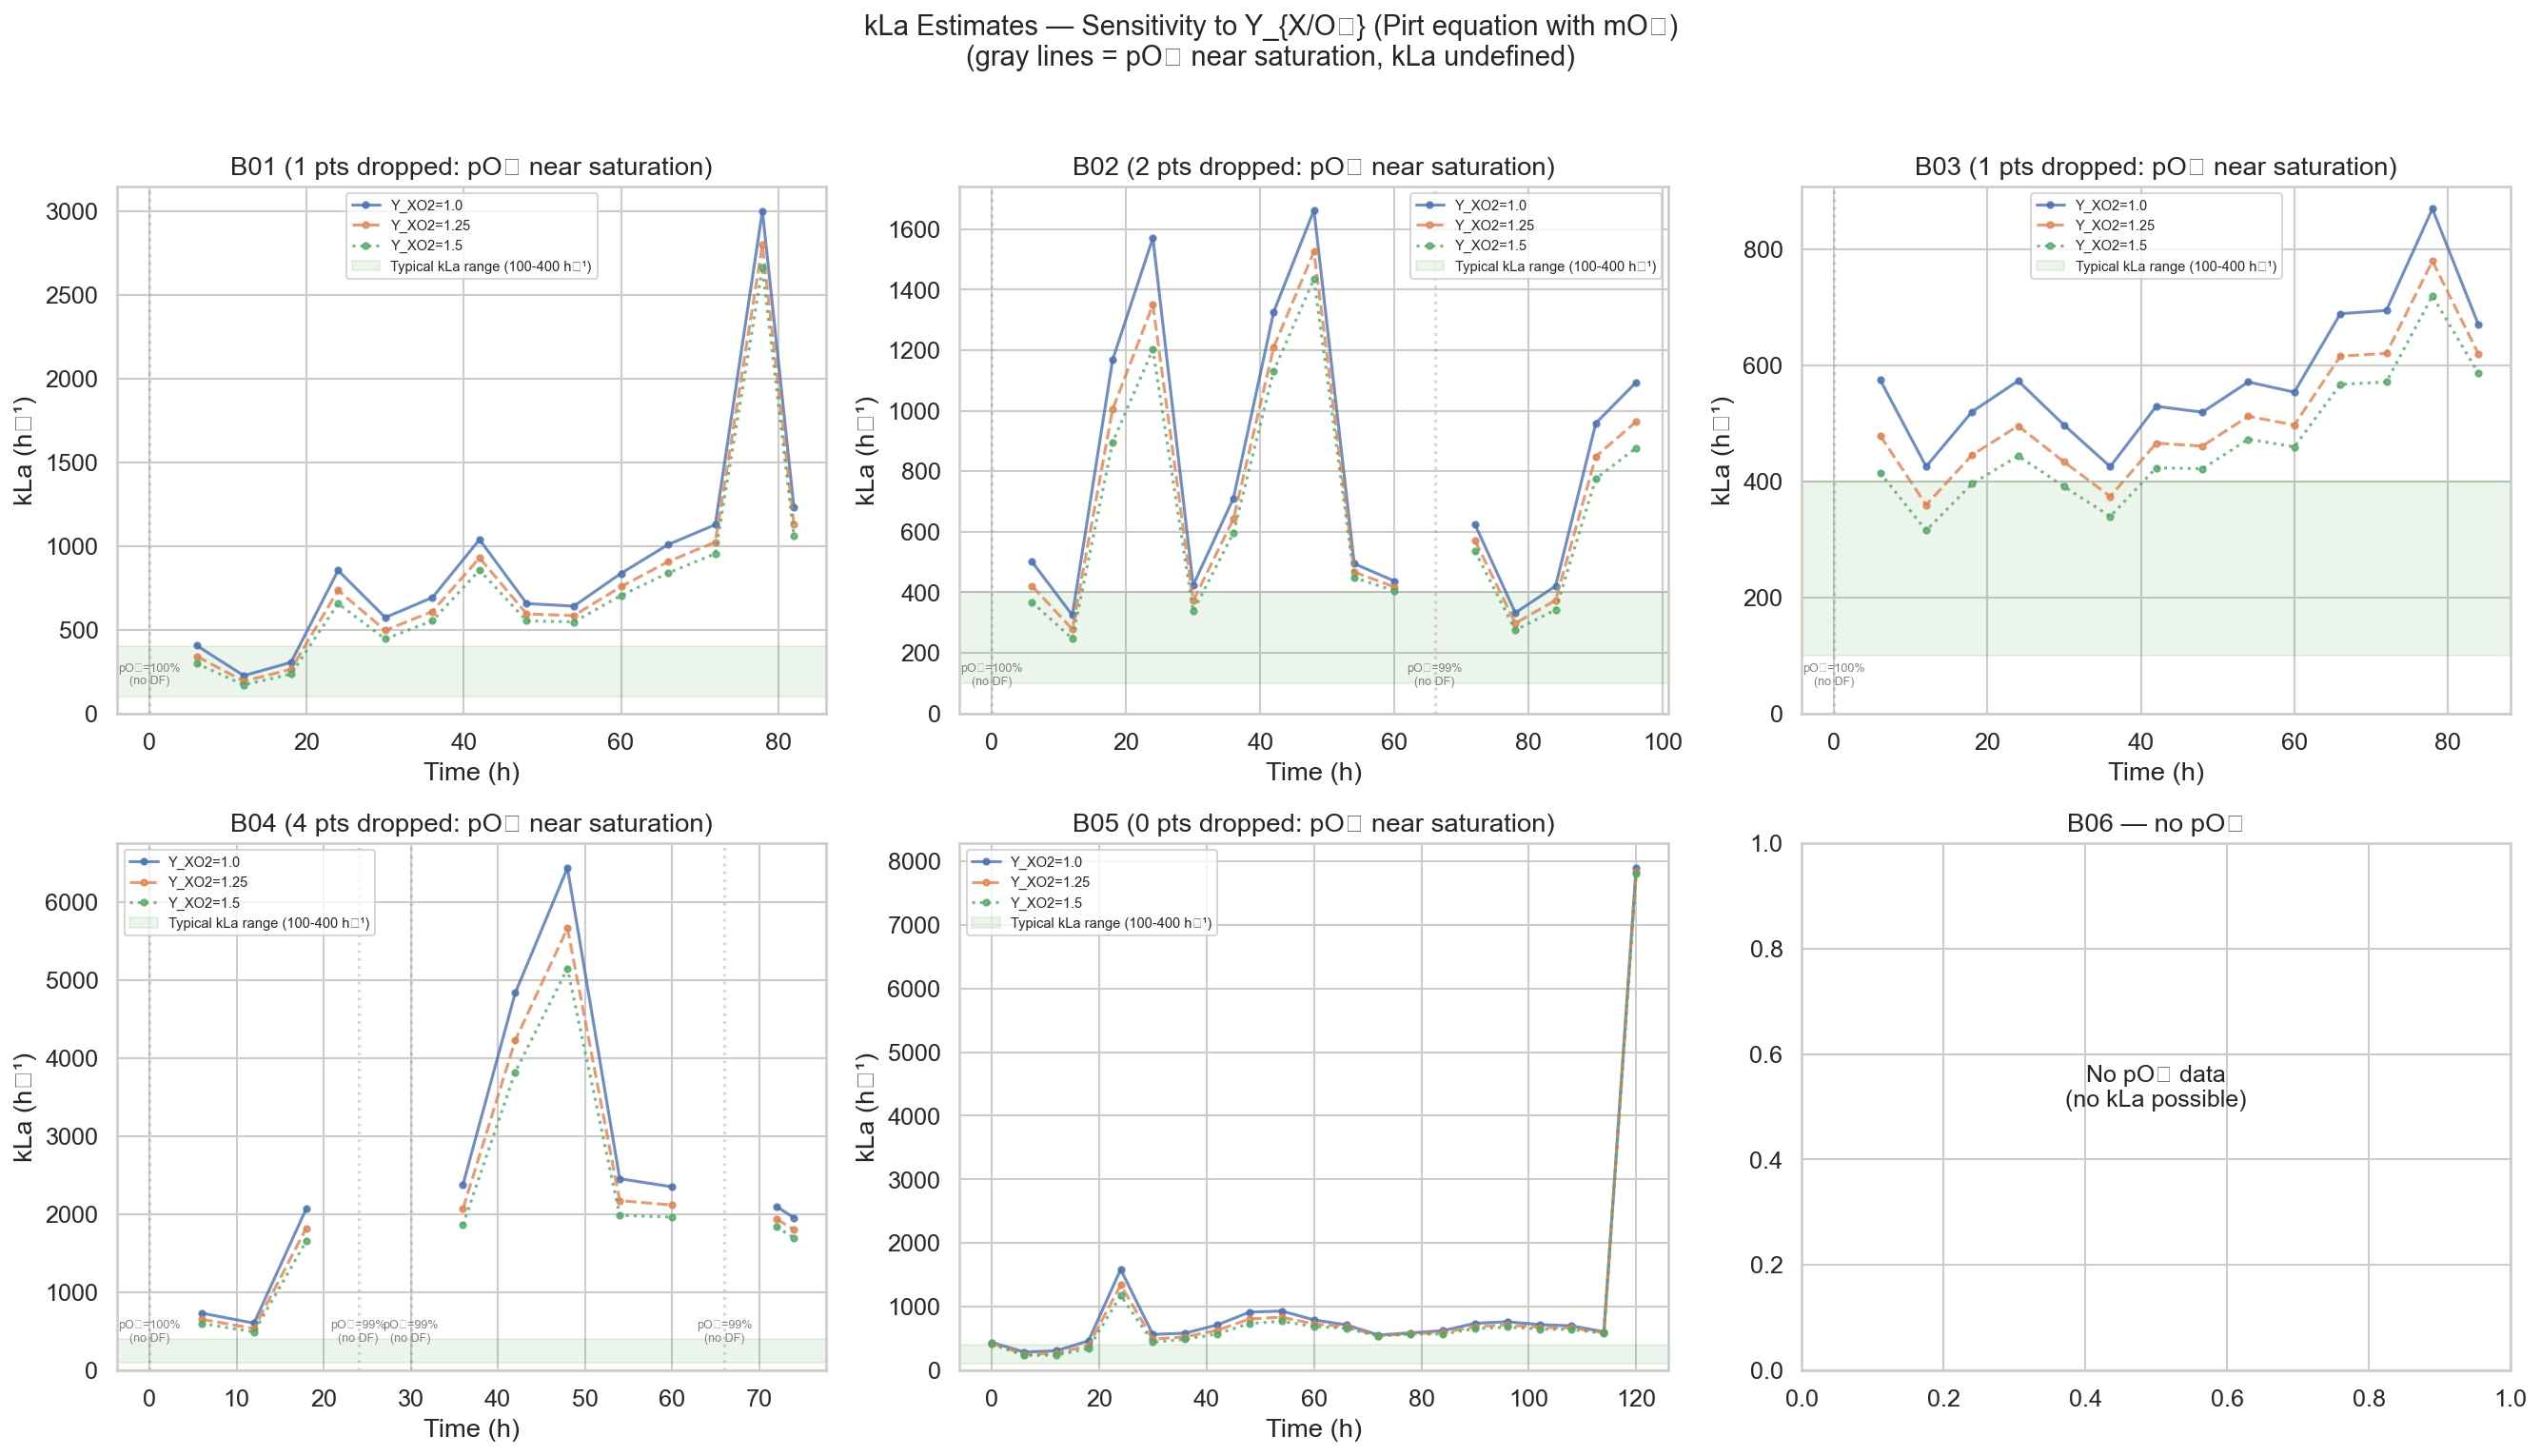

In [19]:
# --- Plot 8b: kLa estimates with sensitivity analysis ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
Y_values = [1.0, 1.25, 1.5]
line_styles = ['-', '--', ':']

for idx, (b, df) in enumerate(sorted(batches.items())):
    ax = axes[idx // 3][idx % 3]
    
    if df['pO2_pct'].isna().all():
        ax.text(0.5, 0.5, 'No pO₂ data\n(no kLa possible)',
                transform=ax.transAxes, ha='center', fontsize=12)
        ax.set_title(f'{b} — no pO₂')
        continue
    
    sens = kla_sensitivity(df, PARAMS, Y_values)
    
    for i, yv in enumerate(Y_values):
        subset = sens[sens['Y_XO2'] == yv]
        ax.plot(subset['Time_h'], subset['kLa_h'],
                f'o{line_styles[i]}', markersize=3,
                label=f'Y_XO2={yv}', alpha=0.8)
    
    # Mark timepoints where kLa could not be calculated (pO2 near saturation)
    C_star = PARAMS['C_star_mgL']
    dropped = df[df['kLa_h'].isna() & df['pO2_pct'].notna()].copy()
    if len(dropped) > 0:
        for _, row in dropped.iterrows():
            ax.axvline(x=row['Time_h'], color='gray', linestyle=':', alpha=0.3)
            ax.annotate(f"pO₂={row['pO2_pct']:.0f}%\n(no DF)",
                        xy=(row['Time_h'], ax.get_ylim()[1] * 0.05 if ax.get_ylim()[1] > 0 else 10),
                        fontsize=6, color='gray', ha='center', va='bottom')
    
    # Typical kLa range for benchtop
    ax.axhspan(100, 400, alpha=0.08, color='green',
               label='Typical kLa range (100-400 h⁻¹)')
    
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('kLa (h⁻¹)')
    ax.set_title(f'{b} ({len(dropped)} pts dropped: pO₂ near saturation)')
    ax.legend(fontsize=7)
    ax.set_ylim(bottom=0)

plt.suptitle('kLa Estimates — Sensitivity to Y_{X/O₂} (Pirt equation with mO₂)\n'
             '(gray lines = pO₂ near saturation, kLa undefined)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# --- Peak OUR and kLa summary table (with Pirt decomposition) ---
kla_summary = []
for b, df in sorted(batches.items()):
    peak_our_idx = df['OUR_mmol_L_h'].idxmax()
    last_idx = df.index[-1]
    
    # Maintenance fraction at peak OUR
    peak_maint_frac = (df.loc[peak_our_idx, 'OUR_maint_mmol_L_h'] /
                       df.loc[peak_our_idx, 'OUR_mmol_L_h'] * 100
                       if df.loc[peak_our_idx, 'OUR_mmol_L_h'] > 0 else 0)
    
    # Maintenance fraction at final timepoint
    final_maint_frac = (df.loc[last_idx, 'OUR_maint_mmol_L_h'] /
                        df.loc[last_idx, 'OUR_mmol_L_h'] * 100
                        if df.loc[last_idx, 'OUR_mmol_L_h'] > 0 else 0)
    
    row = {
        'Batch': b,
        'Peak OUR (mmol/L/h)': round(df.loc[peak_our_idx, 'OUR_mmol_L_h'], 1),
        'Time at peak (h)': df.loc[peak_our_idx, 'Time_h'],
        'DCW at peak (g/L)': round(df.loc[peak_our_idx, 'DCW_gL'], 1),
        'Maint % at peak': f'{peak_maint_frac:.0f}%',
        'Final OUR (mmol/L/h)': round(df.loc[last_idx, 'OUR_mmol_L_h'], 1),
        'Maint % at end': f'{final_maint_frac:.0f}%',
        'pO2 at peak (%)': round(df.loc[peak_our_idx, 'pO2_pct'], 1) if pd.notna(df.loc[peak_our_idx, 'pO2_pct']) else 'N/A',
    }
    if pd.notna(df.loc[peak_our_idx, 'kLa_h']):
        row['Implied kLa (h⁻¹)'] = round(df.loc[peak_our_idx, 'kLa_h'], 0)
    else:
        row['Implied kLa (h⁻¹)'] = 'N/A'
    kla_summary.append(row)

kla_df = pd.DataFrame(kla_summary)
print('OUR & kLa Summary (Pirt equation: growth + maintenance)')
print(f'mO2 = {PARAMS["mO2_mmol_gDCW_h"]} mmol O2/g DCW/h, Y_XO2 = {PARAMS["Y_XO2"]} g/g')
display(kla_df)

In [ ]:
# --- Interactive: kLa sensitivity (Plotly) ---
if HAS_PLOTLY:
    # Pick a batch with pO2 data for detailed interactive view
    for demo_batch in ['B03', 'B01', 'B05']:
        if batches[demo_batch]['pO2_pct'].notna().any():
            break
    
    sens = kla_sensitivity(batches[demo_batch], PARAMS, [1.0, 1.25, 1.5])
    fig = px.line(sens, x='Time_h', y='kLa_h', color='Y_XO2',
                  title=f'{demo_batch}: kLa Sensitivity to Y_XO2',
                  labels={'kLa_h': 'kLa (h⁻¹)', 'Time_h': 'Time (h)'},
                  markers=True)
    fig.add_hrect(y0=100, y1=400, fillcolor='green', opacity=0.1,
                  annotation_text='Typical benchtop kLa', annotation_position='top left')
    fig.show()

---
## Summary: Export All Processed Data

In [ ]:
# Combine all processed batches into one DataFrame and save
all_processed = pd.concat(batches.values(), ignore_index=True)
all_processed.to_csv('processed_batch_data.csv', index=False)
print(f'Saved processed_batch_data.csv ({len(all_processed)} rows, {len(all_processed.columns)} columns)')
print(f'\nColumns: {list(all_processed.columns)}')